## XGBoost from first principles — with a meteorological playground

This notebook is a guided construction of XGBoost from the ground up.

The aim is to understand each facet of it, from first principles, namely:

- how boosting turns many small trees into one strong model;
- why XGBoost uses a **second-order Taylor approximation**;
- what the **gradient** and **Hessian** mean in practice;
- where the famous **gain** formula comes from;
- how leaf values are computed;
- how missing data can be routed without imputation;
- what `eta`, `gamma`, `lambda`, `alpha`, `max_depth`, `min_child_weight`, `subsample`, `colsample_*`, `max_bin`, and friends actually do;
- how different losses change the behaviour of the model;
- how XGBoost's built-in **weight**, **gain**, and **cover** importance summaries differ;
- how all this plays out in a meteorological example: predicting rain amount and rain occurrence from simulated weather station data;
- how explainability works, and how different methods give different interpretations.

The notebook contains a small, readable implementation of an XGBoost-like learner. It is deliberately simpler than production XGBoost, but it uses the same core mathematics: gradients, Hessians, leaf scores, gain, regularisation, shrinkage, column/row sampling, histogram-like split approximation, and learnt missing-value directions.

> **How to use it**
>
> Run the notebook top-to-bottom once. Then return to the interactive cells and play with them!


## 0. Setup

Start by importing required packages and enabling widgets (if available).

Optional packages:

```bash
pip install numpy pandas matplotlib ipywidgets scikit-learn
```

Only `numpy`, `pandas`, and `matplotlib` are needed for the from-scratch parts. `ipywidgets` needed for interactivity. 

In [1]:
import math
import os
import warnings
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, Markdown, clear_output, display

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Use a calmer colour cycle for multi-line examples.
try:
	from cycler import cycler
	plt.rcParams["axes.prop_cycle"] = cycler(color=[
		"#1f77b4", "#2ca02c", "#9467bd", "#8c564b",
		"#7f7f7f", "#17becf", "#bcbd22", "#1b9e77"
	])
except Exception:
	pass

PREGENERATE_FIGURES = os.environ.get("MLWC_PREGENERATE_FIGURES", "0") == "1"

try:
	import ipywidgets as widgets
	from ipywidgets import HBox, VBox, interactive_output
	HAS_WIDGETS = not PREGENERATE_FIGURES
except Exception as exc:
	HAS_WIDGETS = False
	widgets = None
	print("ipywidgets is not available. Interactive cells will show static fallbacks.")
	print(f"Import error: {exc}")

try:
	import sklearn
	HAS_SKLEARN = True
except Exception:
	HAS_SKLEARN = False

try:
	import xgboost as xgb
	HAS_XGBOOST = True
except Exception:
	HAS_XGBOOST = False

RNG = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 80)

def sigmoid(z):
	z = np.asarray(z)
	return 1.0 / (1.0 + np.exp(-np.clip(z, -35, 35)))

def logit(p):
	p = np.clip(p, 1e-6, 1 - 1e-6)
	return np.log(p / (1 - p))

def rmse(y, pred):
	y = np.asarray(y)
	pred = np.asarray(pred)
	return float(np.sqrt(np.mean((y - pred) ** 2)))

def mae(y, pred):
	y = np.asarray(y)
	pred = np.asarray(pred)
	return float(np.mean(np.abs(y - pred)))

def logloss(y, margin):
	p = sigmoid(margin)
	return float(-np.mean(y * np.log(np.clip(p, 1e-12, 1)) + (1 - y) * np.log(np.clip(1 - p, 1e-12, 1))))

def train_valid_split(n, valid_fraction=0.25, seed=0):
	rng = np.random.default_rng(seed)
	idx = rng.permutation(n)
	n_valid = int(round(valid_fraction * n))
	valid_idx = idx[:n_valid]
	train_idx = idx[n_valid:]
	return train_idx, valid_idx

print(f"Interactive widgets enabled: {HAS_WIDGETS}")
print(f"Static figure pre-generation mode: {PREGENERATE_FIGURES}")
print(f"scikit-learn available: {HAS_SKLEARN}")
print(f"xgboost available: {HAS_XGBOOST}")

Interactive widgets enabled: True
Static figure pre-generation mode: False
scikit-learn available: True
xgboost available: True


## 1. The meteorological toy model

A real meteorological workflow would start with carefully quality-controlled observations (usually the most work!), NWP/reanalysis predictors, radar/satellite products, etc.

For our teaching example, we will generate a synthetic station dataset with known meteorological relationships.

- rain is more likely with high relative humidity, cloud, falling pressure, westerly upslope flow, and convective instability;
- rainfall amount is zero-inflated and right-skewed;
- some sensors go missing in non-random ways, so missingness itself can carry information;
- wind direction and month are cyclic, so they are encoded using sine/cosine pairs.

The target variables that we want to model are:

- `rain_next_6h_mm`: simulated rainfall amount over the next 6 hours;
- `rain_next_6h`: binary indicator of measurable rain.

In [2]:
def make_meteo_data(
	n: int = 3500,
	seed: int = 7,
	missingness: float = 0.12,
	storminess: float = 1.0,
	climate_shift_c: float = 0.0,
) -> pd.DataFrame:
	# Create a synthetic meteorological station dataset.
	# This is not a physical model. It is a didactic data generator with plausible
	# nonlinearities, interactions, missingness, and zero-inflated rainfall.
	rng = np.random.default_rng(seed)

	dayofyear = rng.integers(1, 366, size=n)
	hour = rng.integers(0, 24, size=n)
	month = np.clip(((dayofyear - 1) // 30) + 1, 1, 12)

	lat = rng.uniform(49.0, 60.5, size=n)
	elevation_m = np.clip(rng.gamma(shape=2.0, scale=120.0, size=n), 0, 1100)
	distance_to_coast_km = np.clip(rng.exponential(scale=55.0, size=n), 0, 280)

	season = np.sin(2 * np.pi * (dayofyear - 172) / 365.0)
	diurnal = np.sin(2 * np.pi * (hour - 15) / 24.0)

	temp_c = (
		10.5
		+ 8.5 * season
		+ 2.2 * diurnal
		- 0.0062 * elevation_m
		- 0.25 * (lat - 54.5)
		+ climate_shift_c
		+ rng.normal(0, 2.8, size=n)
	)

	dewpoint_depression = rng.gamma(shape=2.2, scale=1.7, size=n) + rng.normal(0, 0.45, size=n)
	dewpoint_c = temp_c - np.clip(dewpoint_depression, 0.2, 18.0)

	es_td = np.exp((17.625 * dewpoint_c) / (243.04 + dewpoint_c))
	es_t = np.exp((17.625 * temp_c) / (243.04 + temp_c))
	rel_humidity = np.clip(100 * es_td / es_t, 25, 100)

	large_scale_low = rng.normal(0, 1, size=n)
	pressure_hpa = 1015.0 - 6.0 * large_scale_low - 0.025 * elevation_m + rng.normal(0, 4.0, size=n)
	pressure_tendency_hpa3h = rng.normal(0.15, 1.2, size=n) - 1.15 * large_scale_low

	wind_speed_ms = np.clip(rng.gamma(shape=2.1, scale=2.1, size=n) + 1.1 * np.maximum(large_scale_low, 0), 0, 28)
	wind_dir_deg = rng.uniform(0, 360, size=n)

	westerly_component = np.cos(np.deg2rad(wind_dir_deg - 270.0))
	upslope_index = np.maximum(0, westerly_component) * (elevation_m / 800.0) * (wind_speed_ms / 10.0)

	convective_season = np.maximum(0, season)
	cape_jkg = np.clip(
		40
		+ 850 * convective_season * sigmoid((temp_c - 14) / 4)
		+ 9 * np.maximum(dewpoint_c, 0)
		+ rng.gamma(1.5, 80, size=n),
		0,
		2500,
	)

	cloud_signal = (
		0.035 * (rel_humidity - 70)
		- 0.55 * pressure_tendency_hpa3h
		+ 0.45 * large_scale_low
		+ 0.25 * upslope_index
		+ rng.normal(0, 1.0, size=n)
	)
	cloud_octas = np.clip(np.round(4.0 + 2.2 * sigmoid(cloud_signal) + rng.normal(0, 1.2, size=n)), 0, 8)

	linear_rain_occurrence = (
		-1.45
		+ storminess * (
			0.055 * (rel_humidity - 76)
			+ 0.34 * (cloud_octas - 4)
			- 0.48 * pressure_tendency_hpa3h
			+ 1.20 * upslope_index
			+ 0.0010 * cape_jkg
			+ 0.045 * wind_speed_ms
		)
		+ rng.normal(0, 0.55, size=n)
	)
	p_rain = sigmoid(linear_rain_occurrence)
	rain_next_6h = rng.binomial(1, p_rain, size=n)

	log_intensity = (
		-0.05
		+ 0.026 * (rel_humidity - 78)
		+ 0.090 * (cloud_octas - 4)
		- 0.27 * pressure_tendency_hpa3h
		+ 1.10 * upslope_index
		+ 0.00075 * cape_jkg
		+ 0.060 * wind_speed_ms
		+ rng.normal(0, 0.62, size=n)
	)
	mean_amount = np.exp(np.clip(log_intensity, -3.0, 4.2))
	rain_amount = rain_next_6h * rng.gamma(shape=1.45, scale=mean_amount / 1.45)

	df = pd.DataFrame({
		"dayofyear": dayofyear,
		"month": month,
		"hour": hour,
		"lat": lat,
		"elevation_m": elevation_m,
		"distance_to_coast_km": distance_to_coast_km,
		"temp_c": temp_c,
		"dewpoint_c": dewpoint_c,
		"rel_humidity": rel_humidity,
		"pressure_hpa": pressure_hpa,
		"pressure_tendency_hpa3h": pressure_tendency_hpa3h,
		"wind_speed_ms": wind_speed_ms,
		"wind_dir_deg": wind_dir_deg,
		"cloud_octas": cloud_octas,
		"cape_jkg": cape_jkg,
		"upslope_index": upslope_index,
		"rain_next_6h": rain_next_6h,
		"rain_next_6h_mm": rain_amount,
	})

	df["wind_dir_sin"] = np.sin(np.deg2rad(df["wind_dir_deg"]))
	df["wind_dir_cos"] = np.cos(np.deg2rad(df["wind_dir_deg"]))
	df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
	df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
	df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
	df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

	prob_dew_missing = missingness * (0.45 + 1.8 * sigmoid((df["rel_humidity"] - 96) / 1.8))
	prob_cape_missing = missingness * (0.55 + 1.5 * (df["month"].isin([11, 12, 1, 2]).astype(float)))
	prob_cloud_missing = missingness * (0.7 + 0.8 * sigmoid((df["wind_speed_ms"] - 12) / 2))
	prob_winddir_missing = missingness * (0.4 + 1.2 * sigmoid((1.2 - df["wind_speed_ms"]) / 0.7))

	for col, prob in [
		("dewpoint_c", prob_dew_missing),
		("rel_humidity", prob_dew_missing * 0.65),
		("cape_jkg", prob_cape_missing),
		("cloud_octas", prob_cloud_missing),
		("wind_dir_deg", prob_winddir_missing),
		("wind_dir_sin", prob_winddir_missing),
		("wind_dir_cos", prob_winddir_missing),
	]:
		mask = rng.random(n) < np.clip(prob, 0, 0.75)
		df.loc[mask, col] = np.nan

	return df


FEATURES = [
	"temp_c",
	"dewpoint_c",
	"rel_humidity",
	"pressure_hpa",
	"pressure_tendency_hpa3h",
	"wind_speed_ms",
	"wind_dir_sin",
	"wind_dir_cos",
	"cloud_octas",
	"cape_jkg",
	"elevation_m",
	"distance_to_coast_km",
	"upslope_index",
	"month_sin",
	"month_cos",
	"hour_sin",
	"hour_cos",
]

df = make_meteo_data()
display(df.head())
print(f"Rows: {len(df):,}")
print(f"Rain frequency: {df['rain_next_6h'].mean():.1%}")
print(f"Mean rain amount: {df['rain_next_6h_mm'].mean():.2f} mm / 6 h")
print("\nMissing fractions:")
display(df[FEATURES].isna().mean().sort_values(ascending=False).to_frame("missing_fraction").T)

,dayofyear,month,hour,lat,elevation_m,distance_to_coast_km,temp_c,dewpoint_c,rel_humidity,pressure_hpa,pressure_tendency_hpa3h,wind_speed_ms,wind_dir_deg,cloud_octas,cape_jkg,upslope_index,rain_next_6h,rain_next_6h_mm,wind_dir_sin,wind_dir_cos,month_sin,month_cos,hour_sin,hour_cos
0,345,12,16,53.738943,155.912415,21.630957,10.911830,9.122321,88.718287,1006.224692,-0.096669,5.502905,123.105512,6.0,368.666216,0.000000,1,1.154024,0.837666,-0.546183,-2.449294e-16,1.000000e+00,-8.660254e-01,-0.500000
1,229,8,21,59.448197,201.262889,4.789062,9.503565,3.981435,NaN,1002.235284,-2.190879,15.071138,240.505133,6.0,441.632856,0.330019,1,18.493750,-0.870400,-0.492346,-8.660254e-01,-5.000000e-01,-7.071068e-01,0.707107
2,250,9,12,60.149793,82.713481,166.723585,15.968750,7.988787,59.111865,1018.378368,2.371489,4.467570,118.271892,NaN,695.934043,0.000000,0,0.000000,0.880710,-0.473656,-1.000000e+00,-1.836970e-16,1.224647e-16,-1.000000
3,328,11,22,59.519909,101.521996,20.228472,18.786256,16.886819,88.731526,1016.066512,2.711004,7.321403,273.186467,4.0,546.772568,0.092767,0,0.000000,-0.998454,0.055586,-5.000000e-01,8.660254e-01,-5.000000e-01,0.866025
4,212,8,4,53.726653,351.751985,116.860452,11.919163,7.161151,72.651132,996.166092,-2.077513,3.845546,213.751466,6.0,374.304832,0.093942,0,0.000000,-0.555592,-0.831455,-8.660254e-01,-5.000000e-01,8.660254e-01,0.500000


Rows: 3,500
Rain frequency: 45.1%
Mean rain amount: 1.83 mm / 6 h

Missing fractions:


,cape_jkg,cloud_octas,dewpoint_c,wind_dir_cos,wind_dir_sin,rel_humidity,temp_c,pressure_tendency_hpa3h,pressure_hpa,wind_speed_ms,elevation_m,distance_to_coast_km,upslope_index,month_sin,month_cos,hour_sin,hour_cos
missing_fraction,0.118571,0.091714,0.068286,0.059143,0.057429,0.046571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


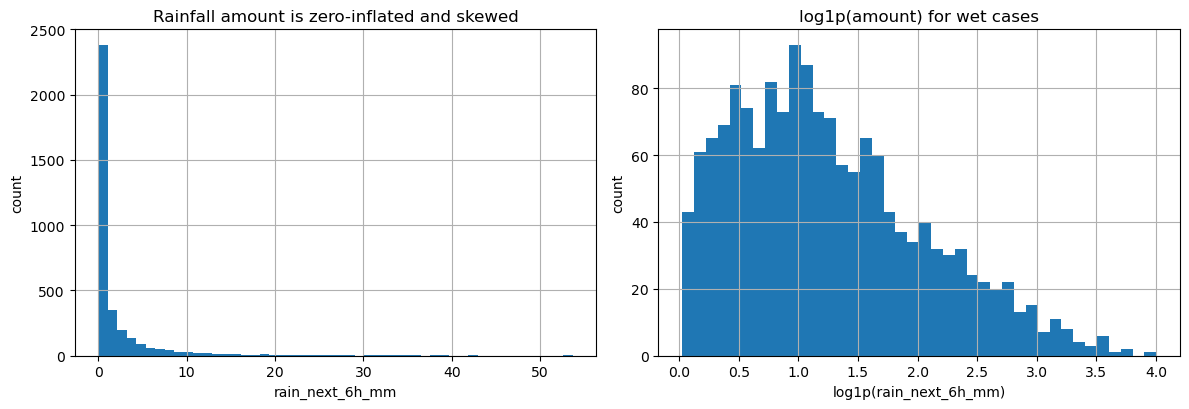

In [3]:
def plot_meteo_overview(df):
	fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
	axes[0].hist(df["rain_next_6h_mm"], bins=50)
	axes[0].set_title("Rainfall amount is zero-inflated and skewed")
	axes[0].set_xlabel("rain_next_6h_mm")
	axes[0].set_ylabel("count")

	positive = df.loc[df["rain_next_6h_mm"] > 0, "rain_next_6h_mm"]
	axes[1].hist(np.log1p(positive), bins=40)
	axes[1].set_title("log1p(amount) for wet cases")
	axes[1].set_xlabel("log1p(rain_next_6h_mm)")
	axes[1].set_ylabel("count")
	plt.tight_layout()
	plt.show()

plot_meteo_overview(df)

In [4]:
def meteo_generator_widget(n=2500, seed=7, missingness=0.12, storminess=1.0, climate_shift_c=0.0):
	tmp = make_meteo_data(
		n=int(n),
		seed=int(seed),
		missingness=float(missingness),
		storminess=float(storminess),
		climate_shift_c=float(climate_shift_c),
	)
	display(tmp.head(4))
	summary = pd.DataFrame({
		"value": [
			len(tmp),
			tmp["rain_next_6h"].mean(),
			tmp["rain_next_6h_mm"].mean(),
			tmp["rain_next_6h_mm"].quantile(0.95),
			tmp[FEATURES].isna().mean().mean(),
		]
	}, index=["rows", "wet fraction", "mean rain mm", "95th percentile rain mm", "mean feature missingness"])
	display(summary)

	fig, ax = plt.subplots(figsize=(8, 3.8))
	ax.hist(tmp["rain_next_6h_mm"], bins=45)
	ax.set_title("Generated rainfall distribution")
	ax.set_xlabel("rain_next_6h_mm")
	ax.set_ylabel("count")
	plt.show()

if HAS_WIDGETS:
	controls = {
		"n": widgets.IntSlider(value=2500, min=500, max=8000, step=500, description="rows"),
		"seed": widgets.IntSlider(value=7, min=0, max=99, step=1, description="seed"),
		"missingness": widgets.FloatSlider(value=0.12, min=0, max=0.4, step=0.02, readout_format=".2f", description="missing"),
		"storminess": widgets.FloatSlider(value=1.0, min=0.2, max=2.0, step=0.1, readout_format=".1f", description="storm"),
		"climate_shift_c": widgets.FloatSlider(value=0.0, min=-3.0, max=4.0, step=0.5, readout_format=".1f", description="ΔT °C"),
	}
	ui = VBox([HBox([controls["n"], controls["seed"]]), HBox([controls["missingness"], controls["storminess"], controls["climate_shift_c"]])])
	out = interactive_output(meteo_generator_widget, controls)
	display(ui, out)
else:
	meteo_generator_widget()

Output()

## 2. From decision trees to boosting

An individual decision tree partitions feature space into "leaves". A regression tree then predicts a constant value in each leaf.

A boosted tree model, like XGBoost, is a **sum of trees**:

$$
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta f_t(x_i)
$$

where:

- $f_t$ is the new tree at boosting round $t$;
- $\eta$, often called `learning_rate`, shrinks each tree before adding it;
- previous mistakes influence the next tree through derivatives of the loss.

In ordinary gradient boosting you often hear: *fit a tree to the residuals*.  
XGBoost is actually a bit cleverer than that, it fit a tree using both the **first derivative** and the **second derivative** of the loss.

The first derivative is the **gradient** $g_i$. It says which way the prediction should move.  
The second derivative is the **Hessian** $h_i$. It says how curved the loss is near the current prediction (you can think of this as a measure of confidence), and it becomes a per-example weight in the split calculations.

In [6]:
def residual_stump_demo(noise=0.15, threshold=0.0, learning_rate=0.4):
	rng = np.random.default_rng(3)
	x = np.linspace(-3, 3, 150)
	y = np.sin(1.4 * x) + 0.35 * (x > 0.8) + rng.normal(0, noise, size=len(x))

	base = np.mean(y)
	resid = y - base

	left = x <= threshold
	right = ~left

	left_value = resid[left].mean() if left.any() else 0.0
	right_value = resid[right].mean() if right.any() else 0.0
	update = np.where(left, left_value, right_value)
	pred1 = base + learning_rate * update

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	axes[0].scatter(x, y, s=18, label="observed")
	axes[0].axhline(base, linestyle="--", label="base prediction")
	axes[0].step(x, pred1, where="mid", label="after one stump")
	axes[0].axvline(threshold, linestyle=":")
	axes[0].set_title("A stump adds a piecewise-constant correction")
	axes[0].legend()

	axes[1].scatter(x, resid, s=18, label="residuals")
	axes[1].step(x, update, where="mid", label="stump fitted to residuals")
	axes[1].axhline(0, linestyle="--")
	axes[1].axvline(threshold, linestyle=":")
	axes[1].set_title("For squared error: negative gradient = residual")
	axes[1].legend()
	plt.tight_layout()
	plt.show()

	print(f"Base prediction = {base:.3f}")
	print(f"Left update = {left_value:.3f}, right update = {right_value:.3f}, learning_rate = {learning_rate:.2f}")

if HAS_WIDGETS:
	display(widgets.interactive(
		residual_stump_demo,
		noise=widgets.FloatSlider(value=0.15, min=0.0, max=0.6, step=0.05, description="noise"),
		threshold=widgets.FloatSlider(value=0.0, min=-2.8, max=2.8, step=0.1, description="split"),
		learning_rate=widgets.FloatSlider(value=0.4, min=0.05, max=1.0, step=0.05, description="eta"),
	))
else:
	residual_stump_demo()

interactive(children=(FloatSlider(value=0.15, description='noise', max=0.6, step=0.05), FloatSlider(value=0.0,…

## 3. The second-order objective

At boosting round $t$, the model already has predictions $\hat{y}_i^{(t-1)}$. We add a new tree $f_t$.

XGBoost minimises a regularised objective:

$$
\mathcal{L}^{(t)}
=
\sum_{i=1}^{n}
\ell\left(y_i,\ \hat{y}_i^{(t-1)} + f_t(x_i)\right)
+
\Omega(f_t)
$$

For a tree with $T$ leaves and leaf weights $w_1,\ldots,w_T$:

$$
\Omega(f_t)
=
\gamma T
+
\frac{1}{2}\lambda\sum_{j=1}^{T}w_j^2
+
\alpha\sum_{j=1}^{T}|w_j|
$$

where:

- `gamma` $(\gamma)$ is the cost of adding a leaf;
- `lambda` $(\lambda)$ is L2 regularisation on leaf values;
- `alpha` $(\alpha)$ is L1 regularisation on leaf values.

Now approximate the loss using Taylor expansion around the current prediction:

$$
\ell(y_i, \hat{y}_i + f_i)
\approx
\ell(y_i, \hat{y}_i)
+
g_i f_i
+
\frac{1}{2} h_i f_i^2
$$

where:

$$
g_i = \frac{\partial \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i},
\qquad
h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}.
$$

For a leaf $j$, all rows in the leaf receive the same value $w_j$. Define:

$$
G_j = \sum_{i \in I_j} g_i,
\qquad
H_j = \sum_{i \in I_j} h_i.
$$

Ignoring constants that do not depend on the new tree, the objective for one leaf is:

$$
G_j w_j + \frac{1}{2}(H_j + \lambda)w_j^2 + \alpha|w_j|.
$$

Without L1 regularisation $(\alpha=0)$, the optimal leaf value is:

$$
w_j^* = -\frac{G_j}{H_j+\lambda}.
$$

In other words, you can think of each leaf as doing gradient divided by curvature, i.e. Newton's method!

### 3.1 Loss functions: gradients and Hessians

XGboost also distinguishes the **raw model score** from the transformed prediction.

In a regression task, $m$ is the predicted value. In a logistic classification task, $m$ is the log-odds before conversion to a probabilty (given by $p=\sigma(m)$). Derivatives are taken with respect to the raw score $m$.

| Task | Loss | Gradient $g$ | Hessian $h$ |
|---|---:|---:|---:|
| Squared regression | $\frac{1}{2}(m-y)^2$ | $m-y$ | $1$ |
| Logistic classification | $-y\log p-(1-y)\log(1-p)$ | $p-y$ | $p(1-p)$ |
| Poisson count regression | $\exp(m)-ym$ | $\exp(m)-y$ | $\exp(m)$ |
| Pseudo-Huber regression | $\delta^2(\sqrt{1+((m-y)/\delta)^2}-1)$ | $\frac{m-y}{\sqrt{1+((m-y)/\delta)^2}}$ | $\left(1+((m-y)/\delta)^2\right)^{-3/2}$ |

The Poisson loss above omits a constant term involving $y!$, which does not affect training.

In [8]:
class Loss:
	def __init__(self, name, loss, grad_hess, init_score, transform=lambda m: m, metric=None):
		self.name = name
		self.loss = loss
		self.grad_hess = grad_hess
		self.init_score = init_score
		self.transform = transform
		self.metric = metric if metric is not None else loss

def make_loss(name="squared", huber_delta=1.0):
	if name == "squared":
		def loss(y, m):
			return 0.5 * (m - y) ** 2

		def grad_hess(y, m):
			return m - y, np.ones_like(y, dtype=float)

		def init_score(y):
			return float(np.nanmean(y))

		return Loss("squared", loss, grad_hess, init_score, transform=lambda m: m)

	if name == "logistic":
		def loss(y, m):
			p = sigmoid(m)
			return -(y * np.log(np.clip(p, 1e-12, 1)) + (1 - y) * np.log(np.clip(1 - p, 1e-12, 1)))

		def grad_hess(y, m):
			p = sigmoid(m)
			return p - y, np.clip(p * (1 - p), 1e-8, None)

		def init_score(y):
			return float(logit(np.nanmean(y)))

		return Loss("logistic", loss, grad_hess, init_score, transform=sigmoid)

	if name == "poisson":
		def loss(y, m):
			mu = np.exp(np.clip(m, -20, 20))
			return mu - y * m

		def grad_hess(y, m):
			mu = np.exp(np.clip(m, -20, 20))
			return mu - y, np.clip(mu, 1e-8, None)

		def init_score(y):
			return float(np.log(np.nanmean(y) + 1e-6))

		return Loss("poisson", loss, grad_hess, init_score, transform=lambda m: np.exp(np.clip(m, -20, 20)))

	if name == "pseudo_huber":
		delta = float(huber_delta)

		def loss(y, m):
			r = m - y
			z = r / delta
			return delta ** 2 * (np.sqrt(1 + z ** 2) - 1)

		def grad_hess(y, m):
			r = m - y
			z = r / delta
			return r / np.sqrt(1 + z ** 2), (1 + z ** 2) ** (-1.5)

		def init_score(y):
			return float(np.nanmedian(y))

		return Loss("pseudo_huber", loss, grad_hess, init_score, transform=lambda m: m)

	raise ValueError(f"Unknown loss: {name}")

def plot_loss_derivatives(loss_name="logistic", y_value=1.0, huber_delta=1.0):
	loss = make_loss(loss_name, huber_delta=huber_delta)
	m = np.linspace(-6, 6, 500)
	y = np.full_like(m, y_value, dtype=float)

	if loss_name == "poisson":
		m = np.linspace(-3, 3, 500)
		y = np.full_like(m, max(y_value, 0.0), dtype=float)

	g, h = loss.grad_hess(y, m)
	L = loss.loss(y, m)

	fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
	axes[0].plot(m, L)
	axes[0].set_title("Loss")
	axes[0].set_xlabel("raw score / prediction m")

	axes[1].plot(m, g)
	axes[1].axhline(0, linestyle="--")
	axes[1].set_title("Gradient g")
	axes[1].set_xlabel("m")

	axes[2].plot(m, h)
	axes[2].set_title("Hessian h")
	axes[2].set_xlabel("m")

	plt.suptitle(f"{loss.name} loss, y={y_value:g}")
	plt.tight_layout()
	plt.show()

	print("Interpretation:")
	print("- gradient tells the new tree which direction to push the prediction")
	print("- Hessian acts like local curvature / confidence / weight")
	print("- leaf update is roughly -sum(gradient) / (sum(Hessian) + lambda)")

if HAS_WIDGETS:
	display(widgets.interactive(
		plot_loss_derivatives,
		loss_name=widgets.Dropdown(options=["squared", "logistic", "poisson", "pseudo_huber"], value="logistic", description="loss"),
		y_value=widgets.FloatSlider(value=1.0, min=0.0, max=8.0, step=0.5, description="y"),
		huber_delta=widgets.FloatSlider(value=1.0, min=0.2, max=5.0, step=0.2, description="δ"),
	))
else:
	plot_loss_derivatives()

interactive(children=(Dropdown(description='loss', index=1, options=('squared', 'logistic', 'poisson', 'pseudo…

In [10]:
def taylor_approximation_demo(loss_name="logistic", y_value=1.0, expansion_point=0.0, huber_delta=1.0):
	loss = make_loss(loss_name, huber_delta=huber_delta)

	if loss_name == "poisson":
		grid = np.linspace(-3, 3, 500)
	else:
		grid = np.linspace(-6, 6, 500)

	y_grid = np.full_like(grid, y_value, dtype=float)
	exact = loss.loss(y_grid, grid)

	y0 = np.array([y_value], dtype=float)
	m0 = np.array([expansion_point], dtype=float)
	L0 = float(loss.loss(y0, m0)[0])
	g0, h0 = loss.grad_hess(y0, m0)
	g0 = float(g0[0])
	h0 = float(h0[0])

	d = grid - expansion_point
	first_order = L0 + g0 * d
	second_order = L0 + g0 * d + 0.5 * h0 * d ** 2

	plt.figure(figsize=(8.5, 5))
	plt.plot(grid, exact, label="exact loss")
	plt.plot(grid, first_order, linestyle="--", label="first-order approximation")
	plt.plot(grid, second_order, linestyle=":", label="second-order approximation")
	plt.axvline(expansion_point, linestyle="-.", label="current prediction")
	plt.ylim(np.nanmin(exact) - 0.2, np.nanpercentile(exact, 95) + 0.5)
	plt.xlabel("raw score / prediction m")
	plt.ylabel("loss")
	plt.title("Why XGBoost uses gradient and Hessian")
	plt.legend()
	plt.show()

	print(f"At m0={expansion_point:.2f}: loss={L0:.4f}, gradient={g0:.4f}, Hessian={h0:.4f}")
	print("The second-order curve is the local bowl that XGBoost optimises to choose a tree.")

if HAS_WIDGETS:
	display(widgets.interactive(
		taylor_approximation_demo,
		loss_name=widgets.Dropdown(options=["squared", "logistic", "poisson", "pseudo_huber"], value="logistic", description="loss"),
		y_value=widgets.FloatSlider(value=1.0, min=0.0, max=8.0, step=0.5, description="y"),
		expansion_point=widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.25, description="m0"),
		huber_delta=widgets.FloatSlider(value=1.0, min=0.2, max=5.0, step=0.2, description="δ"),
	))
else:
	taylor_approximation_demo()

interactive(children=(Dropdown(description='loss', index=1, options=('squared', 'logistic', 'poisson', 'pseudo…

## 4. Leaf score and split gain

The objective here is the second-order, regularised objective introduced in Section 3. Once a tree structure assigns observations to leaves, that objective separates into one contribution per leaf.

For a leaf containing observations $I$, define:

$$
G=\sum_{i\in I}g_i,
\qquad
H=\sum_{i\in I}h_i.
$$

Because every observation in the leaf receives the same correction $w$, the part of the approximate objective that depends on this leaf is:

$$
\widetilde{\mathcal L}_{\mathrm{leaf}}(w)
=
Gw+\frac{1}{2}(H+\lambda)w^2,
$$

where terms independent of $w$ have been omitted.

The first term measures how the correction changes the loss. The quadratic term limits its size according to both the curvature $H$ and the L2 penalty $\lambda$.

Differentiating and setting the result to zero gives:

$$
G+(H+\lambda)w=0,
$$

so the best leaf value is:

$$
w^*=-\frac{G}{H+\lambda}.
$$

Substituting $w^*$ back into the leaf objective gives:

$$
\widetilde{\mathcal L}_{\mathrm{leaf}}(w^*)
=
-\frac{1}{2}\frac{G^2}{H+\lambda}.
$$

This is negative because the optimised leaf reduces the approximate objective. XGBoost conventionally expresses the magnitude of that reduction as a positive **leaf score**:

$$
\operatorname{Score}(G,H)
=
\frac{1}{2}\frac{G^2}{H+\lambda}.
$$

The score is therefore not a separate objective. It is the improvement obtained after choosing the best value for that leaf.

### Split gain

A split replaces one parent leaf with left and right child leaves. Its gain is:

$$
\operatorname{Gain}
=
\operatorname{Score}(G_L,H_L)
+
\operatorname{Score}(G_R,H_R)
-
\operatorname{Score}(G,H)
-
\gamma.
$$

Equivalently:

$$
\operatorname{Gain}
=
\frac{1}{2}
\left[
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-
\frac{G^2}{H+\lambda}
\right]
-
\gamma.
$$

Thus, a split is accepted only when its two specialised corrections improve the objective more than the single parent correction, by enough to pay the additional complexity cost $\gamma$.

With L1 regularisation, replace $G$ by its soft-thresholded value:

$$
S(G,\alpha)
=
\operatorname{sign}(G)\max(|G|-\alpha,0).
$$

The leaf value then becomes:

$$
w^*=-\frac{S(G,\alpha)}{H+\lambda},
$$

and every $G^2$ term in the score and gain formula becomes $S(G,\alpha)^2$.

Interpretation:

- $G$: the combined direction and strength of the requested correction;
- $H$: the curvature of the loss, acting as an effective weight;
- $\lambda$: shrinkage of leaf values towards zero;
- $\alpha$: removal of weak corrections;
- $\gamma$: the improvement required to justify an additional split.
```

In [12]:
def soft_threshold_abs(G, alpha):
	return np.maximum(np.abs(G) - alpha, 0.0)

def xgb_score(G, H, reg_lambda=1.0, reg_alpha=0.0):
	return soft_threshold_abs(G, reg_alpha) ** 2 / (H + reg_lambda)

def leaf_weight_from_gh(G, H, reg_lambda=1.0, reg_alpha=0.0, max_delta_step=0.0):
	if abs(G) <= reg_alpha:
		w = 0.0
	else:
		w = -np.sign(G) * (abs(G) - reg_alpha) / (H + reg_lambda)
	if max_delta_step and max_delta_step > 0:
		w = float(np.clip(w, -max_delta_step, max_delta_step))
	return float(w)

def split_gain_from_gh(GL, HL, GR, HR, reg_lambda=1.0, reg_alpha=0.0, gamma=0.0):
	G = GL + GR
	H = HL + HR
	gain = 0.5 * (
		xgb_score(GL, HL, reg_lambda, reg_alpha)
		+ xgb_score(GR, HR, reg_lambda, reg_alpha)
		- xgb_score(G, H, reg_lambda, reg_alpha)
	) - gamma
	return float(gain)

def gain_calculator(GL=-8.0, HL=20.0, GR=5.0, HR=20.0, reg_lambda=1.0, reg_alpha=0.0, gamma=0.0):
	G = GL + GR
	H = HL + HR
	w_parent = leaf_weight_from_gh(G, H, reg_lambda, reg_alpha)
	w_left = leaf_weight_from_gh(GL, HL, reg_lambda, reg_alpha)
	w_right = leaf_weight_from_gh(GR, HR, reg_lambda, reg_alpha)
	gain = split_gain_from_gh(GL, HL, GR, HR, reg_lambda, reg_alpha, gamma)

	table = pd.DataFrame({
		"G": [G, GL, GR],
		"H": [H, HL, HR],
		"optimal leaf value w*": [w_parent, w_left, w_right],
		"score contribution": [
			0.5 * xgb_score(G, H, reg_lambda, reg_alpha),
			0.5 * xgb_score(GL, HL, reg_lambda, reg_alpha),
			0.5 * xgb_score(GR, HR, reg_lambda, reg_alpha),
		],
	}, index=["parent", "left", "right"])
	display(table)

	print(f"Split gain = {gain:.4f}")
	if gain > 0:
		print("The split pays for itself.")
	else:
		print("The split does not pay for itself; XGBoost would prune/reject it.")

	fig, ax = plt.subplots(figsize=(7, 3.8))
	labels = ["parent", "left", "right"]
	values = [w_parent, w_left, w_right]
	ax.bar(labels, values)
	ax.axhline(0, linestyle="--")
	ax.set_ylabel("leaf value")
	ax.set_title("Leaf values implied by G, H, lambda, alpha")
	plt.show()

if HAS_WIDGETS:
	display(widgets.interactive(
		gain_calculator,
		GL=widgets.FloatSlider(value=-8.0, min=-30, max=30, step=1, description="G left"),
		HL=widgets.FloatSlider(value=20.0, min=0.1, max=80, step=1, description="H left"),
		GR=widgets.FloatSlider(value=5.0, min=-30, max=30, step=1, description="G right"),
		HR=widgets.FloatSlider(value=20.0, min=0.1, max=80, step=1, description="H right"),
		reg_lambda=widgets.FloatSlider(value=1.0, min=0, max=30, step=0.5, description="lambda"),
		reg_alpha=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="alpha"),
		gamma=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="gamma"),
	))
else:
	gain_calculator()

interactive(children=(FloatSlider(value=-8.0, description='G left', max=30.0, min=-30.0, step=1.0), FloatSlide…

## 5. Split gain on a meteorological feature

Let us compute the gain of a single split on one feature.

For a log-rain regression target, use:

$$
z_i = \log(1 + \text{rain}_{i})
$$

and squared error loss. At the initial constant prediction, the gradient is:

$$
g_i = \hat{z}_0 - z_i,
\qquad
h_i = 1.
$$

The code below:

1. chooses a feature;
2. chooses a split threshold by percentile of non-missing values;
3. computes gain;
4. tries two missing-value routes: missing goes left, or missing goes right.

In [13]:
def single_feature_split_report(
	feature="rel_humidity",
	percentile=70,
	missing_go_left=True,
	reg_lambda=1.0,
	reg_alpha=0.0,
	gamma=0.0,
	seed=7,
	missingness=0.12,
):
	tmp = make_meteo_data(n=2500, seed=seed, missingness=missingness)
	y = np.log1p(tmp["rain_next_6h_mm"].to_numpy())
	m0 = np.full_like(y, np.mean(y))
	g = m0 - y
	h = np.ones_like(y)

	x = tmp[feature].to_numpy(dtype=float)
	not_missing = np.isfinite(x)
	if not_missing.sum() < 5:
		print("Too few non-missing values.")
		return

	threshold = np.nanpercentile(x, percentile)

	left_nonmiss = not_missing & (x <= threshold)
	right_nonmiss = not_missing & (x > threshold)
	missing = ~not_missing

	if missing_go_left:
		left = left_nonmiss | missing
		right = right_nonmiss
	else:
		left = left_nonmiss
		right = right_nonmiss | missing

	GL, HL = g[left].sum(), h[left].sum()
	GR, HR = g[right].sum(), h[right].sum()
	gain = split_gain_from_gh(GL, HL, GR, HR, reg_lambda, reg_alpha, gamma)

	report = pd.DataFrame({
		"rows": [left.sum(), right.sum(), missing.sum()],
		"G": [GL, GR, g[missing].sum()],
		"H": [HL, HR, h[missing].sum()],
	}, index=["left", "right", "missing-only"])
	display(report)

	print(f"Feature: {feature}")
	print(f"Threshold: {threshold:.3f} ({percentile}th percentile of non-missing values)")
	print(f"Missing default direction: {'left' if missing_go_left else 'right'}")
	print(f"Gain: {gain:.4f}")

	fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
	axes[0].scatter(x[not_missing], y[not_missing], s=13, alpha=0.5)
	axes[0].axvline(threshold, linestyle="--")
	axes[0].set_xlabel(feature)
	axes[0].set_ylabel("log1p(rain_next_6h_mm)")
	axes[0].set_title("Target versus candidate split")

	grid = np.linspace(1, 99, 80)
	gains_left = []
	gains_right = []
	for q in grid:
		th = np.nanpercentile(x, q)
		L0 = not_missing & (x <= th)
		R0 = not_missing & (x > th)
		for_go_left = [
			(L0 | missing, R0),
			(L0, R0 | missing),
		]
		row_gains = []
		for L, R in for_go_left:
			if L.sum() == 0 or R.sum() == 0:
				row_gains.append(np.nan)
			else:
				row_gains.append(split_gain_from_gh(g[L].sum(), h[L].sum(), g[R].sum(), h[R].sum(), reg_lambda, reg_alpha, gamma))
		gains_left.append(row_gains[0])
		gains_right.append(row_gains[1])

	axes[1].plot(grid, gains_left, label="missing left")
	axes[1].plot(grid, gains_right, label="missing right")
	axes[1].axvline(percentile, linestyle="--")
	axes[1].axhline(0, linestyle=":")
	axes[1].set_xlabel("threshold percentile")
	axes[1].set_ylabel("gain")
	axes[1].set_title("Gain curve across thresholds")
	axes[1].legend()
	plt.tight_layout()
	plt.show()

if HAS_WIDGETS:
	display(widgets.interactive(
		single_feature_split_report,
		feature=widgets.Dropdown(options=FEATURES, value="rel_humidity", description="feature"),
		percentile=widgets.IntSlider(value=70, min=1, max=99, step=1, description="percentile"),
		missing_go_left=widgets.Checkbox(value=True, description="missing left"),
		reg_lambda=widgets.FloatSlider(value=1.0, min=0, max=20, step=0.5, description="lambda"),
		reg_alpha=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="alpha"),
		gamma=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="gamma"),
		seed=widgets.IntSlider(value=7, min=0, max=99, step=1, description="seed"),
		missingness=widgets.FloatSlider(value=0.12, min=0, max=0.4, step=0.02, description="missing"),
	))
else:
	single_feature_split_report()

interactive(children=(Dropdown(description='feature', index=2, options=('temp_c', 'dewpoint_c', 'rel_humidity'…

## 6. Building a small XGBoost-like learner

Now let's implement everything we've learned to make a basic XGBoost-like algorithm.

This miniature learner supports:

- second-order split gain;
- L2 and L1 regularisation;
- `gamma`;
- `max_depth`;
- `min_child_weight`;
- `learning_rate`;
- row subsampling;
- column subsampling by node;
- learnt missing-value directions;
- optional histogram-like candidate split approximation with `max_bin`;
- squared, logistic, Poisson, and pseudo-Huber objectives.

It does **not** implement the systems engineering that makes real XGBoost fast at scale, namely cache-aware blocks, distributed training, external memory, GPU kernels, weighted quantile sketch, and so on.

In [14]:
@dataclass
class TreeNode:
	depth: int
	n_samples: int
	G: float
	H: float
	weight: float
	is_leaf: bool = True
	feature: Optional[int] = None
	threshold: Optional[float] = None
	default_left: bool = True
	gain: float = 0.0
	left: Optional[Any] = None
	right: Optional[Any] = None

class ScratchXGBTree:
	def __init__(
		self,
		max_depth=3,
		min_child_weight=1.0,
		gamma=0.0,
		reg_lambda=1.0,
		reg_alpha=0.0,
		max_delta_step=0.0,
		min_samples_split=10,
		colsample_bynode=1.0,
		max_bin=None,
		max_candidates=64,
		random_state=0,
	):
		self.max_depth = int(max_depth)
		self.min_child_weight = float(min_child_weight)
		self.gamma = float(gamma)
		self.reg_lambda = float(reg_lambda)
		self.reg_alpha = float(reg_alpha)
		self.max_delta_step = float(max_delta_step)
		self.min_samples_split = int(min_samples_split)
		self.colsample_bynode = float(colsample_bynode)
		self.max_bin = None if max_bin is None else int(max_bin)
		self.max_candidates = int(max_candidates)
		self.random_state = int(random_state)
		self.rng = np.random.default_rng(self.random_state)
		self.root = None
		self.feature_names = None
		self.feature_importance_gain_ = {}

	def fit(self, X, g, h, feature_names=None):
		self.X = np.asarray(X, dtype=float)
		self.g = np.asarray(g, dtype=float)
		self.h = np.asarray(h, dtype=float)
		self.feature_names = list(feature_names) if feature_names is not None else [f"f{i}" for i in range(self.X.shape[1])]
		self.feature_importance_gain_ = {}
		idx = np.arange(self.X.shape[0])
		self.root = self._build_node(idx, depth=0)
		return self

	def _node_weight(self, idx):
		G = float(self.g[idx].sum())
		H = float(self.h[idx].sum())
		return leaf_weight_from_gh(G, H, self.reg_lambda, self.reg_alpha, self.max_delta_step), G, H

	def _candidate_thresholds(self, values, weights):
		v = values[np.isfinite(values)]
		if len(v) < 2:
			return np.array([])
		unique = np.unique(v)
		if len(unique) < 2:
			return np.array([])

		if self.max_bin is not None and self.max_bin > 1:
			q = np.linspace(0, 1, min(self.max_bin + 1, len(unique) + 1))[1:-1]
			candidates = np.quantile(v, q)
			return np.unique(candidates)

		mids = (unique[:-1] + unique[1:]) / 2
		if len(mids) > self.max_candidates:
			take = np.linspace(0, len(mids) - 1, self.max_candidates).round().astype(int)
			mids = mids[take]
		return mids

	def _choose_features(self, n_features):
		if self.colsample_bynode >= 1:
			return np.arange(n_features)
		k = max(1, int(math.ceil(self.colsample_bynode * n_features)))
		return np.sort(self.rng.choice(n_features, size=k, replace=False))

	def _best_split(self, idx):
		Xn = self.X[idx]
		gn = self.g[idx]
		hn = self.h[idx]
		n_features = Xn.shape[1]
		best = None
		parent_G = float(gn.sum())
		parent_H = float(hn.sum())

		for j in self._choose_features(n_features):
			x = Xn[:, j]
			not_missing = np.isfinite(x)
			if not_missing.sum() < 2:
				continue

			thresholds = self._candidate_thresholds(x, hn)
			if len(thresholds) == 0:
				continue

			miss = ~not_missing
			G_miss = float(gn[miss].sum())
			H_miss = float(hn[miss].sum())
			n_miss = int(miss.sum())

			for th in thresholds:
				left_non = not_missing & (x <= th)
				right_non = not_missing & (x > th)
				if left_non.sum() == 0 or right_non.sum() == 0:
					continue

				GL_non = float(gn[left_non].sum())
				HL_non = float(hn[left_non].sum())
				GR_non = float(gn[right_non].sum())
				HR_non = float(hn[right_non].sum())

				for default_left in [True, False]:
					if default_left:
						GL = GL_non + G_miss
						HL = HL_non + H_miss
						GR = GR_non
						HR = HR_non
						n_left = int(left_non.sum() + n_miss)
						n_right = int(right_non.sum())
					else:
						GL = GL_non
						HL = HL_non
						GR = GR_non + G_miss
						HR = HR_non + H_miss
						n_left = int(left_non.sum())
						n_right = int(right_non.sum() + n_miss)

					if HL < self.min_child_weight or HR < self.min_child_weight:
						continue
					if n_left < 1 or n_right < 1:
						continue

					gain = split_gain_from_gh(GL, HL, GR, HR, self.reg_lambda, self.reg_alpha, self.gamma)
					if best is None or gain > best["gain"]:
						best = {
							"feature": j,
							"threshold": float(th),
							"default_left": bool(default_left),
							"gain": float(gain),
							"parent_G": parent_G,
							"parent_H": parent_H,
						}

		return best

	def _build_node(self, idx, depth):
		weight, G, H = self._node_weight(idx)
		node = TreeNode(depth=depth, n_samples=len(idx), G=G, H=H, weight=weight)

		if depth >= self.max_depth:
			return node
		if len(idx) < self.min_samples_split:
			return node
		if H < self.min_child_weight:
			return node

		best = self._best_split(idx)
		if best is None or best["gain"] <= 0:
			return node

		j = best["feature"]
		x = self.X[idx, j]
		not_missing = np.isfinite(x)
		if best["default_left"]:
			left_mask = (not_missing & (x <= best["threshold"])) | (~not_missing)
		else:
			left_mask = not_missing & (x <= best["threshold"])

		left_idx = idx[left_mask]
		right_idx = idx[~left_mask]
		if len(left_idx) == 0 or len(right_idx) == 0:
			return node

		node.is_leaf = False
		node.feature = j
		node.threshold = best["threshold"]
		node.default_left = best["default_left"]
		node.gain = best["gain"]
		name = self.feature_names[j]
		self.feature_importance_gain_[name] = self.feature_importance_gain_.get(name, 0.0) + best["gain"]
		node.left = self._build_node(left_idx, depth + 1)
		node.right = self._build_node(right_idx, depth + 1)
		return node

	def predict_row(self, row):
		node = self.root
		while not node.is_leaf:
			value = row[node.feature]
			if not np.isfinite(value):
				go_left = node.default_left
			else:
				go_left = value <= node.threshold
			node = node.left if go_left else node.right
		return node.weight

	def predict(self, X):
		X = np.asarray(X, dtype=float)
		return np.array([self.predict_row(row) for row in X])

	def describe(self, node=None, indent=""):
		if node is None:
			node = self.root
		if node.is_leaf:
			return f"{indent}leaf: w={node.weight:+.4f}, G={node.G:+.2f}, H={node.H:.2f}, n={node.n_samples}\n"
		name = self.feature_names[node.feature]
		miss = "left" if node.default_left else "right"
		txt = f"{indent}if {name} <= {node.threshold:.4g}  (missing → {miss}, gain={node.gain:.4f}, n={node.n_samples})\n"
		txt += self.describe(node.left, indent + "  ")
		txt += f"{indent}else\n"
		txt += self.describe(node.right, indent + "  ")
		return txt

class ScratchXGBoost:
	def __init__(
		self,
		n_estimators=30,
		learning_rate=0.1,
		objective="squared",
		huber_delta=1.0,
		max_depth=3,
		min_child_weight=1.0,
		gamma=0.0,
		reg_lambda=1.0,
		reg_alpha=0.0,
		max_delta_step=0.0,
		subsample=1.0,
		colsample_bynode=1.0,
		max_bin=None,
		max_candidates=64,
		min_samples_split=10,
		random_state=0,
	):
		self.n_estimators = int(n_estimators)
		self.learning_rate = float(learning_rate)
		self.objective = objective
		self.huber_delta = float(huber_delta)
		self.max_depth = int(max_depth)
		self.min_child_weight = float(min_child_weight)
		self.gamma = float(gamma)
		self.reg_lambda = float(reg_lambda)
		self.reg_alpha = float(reg_alpha)
		self.max_delta_step = float(max_delta_step)
		self.subsample = float(subsample)
		self.colsample_bynode = float(colsample_bynode)
		self.max_bin = max_bin
		self.max_candidates = int(max_candidates)
		self.min_samples_split = int(min_samples_split)
		self.random_state = int(random_state)
		self.rng = np.random.default_rng(self.random_state)

	def fit(self, X, y, feature_names=None, eval_set=None, sample_weight=None, verbose=False):
		X = np.asarray(X, dtype=float)
		y = np.asarray(y, dtype=float)
		self.feature_names = list(feature_names) if feature_names is not None else [f"f{i}" for i in range(X.shape[1])]
		self.loss_ = make_loss(self.objective, huber_delta=self.huber_delta)
		self.base_score_ = self.loss_.init_score(y)
		self.trees_ = []
		self.history_ = []
		self.feature_importance_gain_ = {}

		margin = np.full(len(y), self.base_score_, dtype=float)
		eval_margin = None
		if eval_set is not None:
			X_eval, y_eval = eval_set
			X_eval = np.asarray(X_eval, dtype=float)
			y_eval = np.asarray(y_eval, dtype=float)
			eval_margin = np.full(len(y_eval), self.base_score_, dtype=float)

		weights = np.ones_like(y, dtype=float) if sample_weight is None else np.asarray(sample_weight, dtype=float)

		for t in range(self.n_estimators):
			g, h = self.loss_.grad_hess(y, margin)
			g = g * weights
			h = h * weights

			if self.subsample < 1.0:
				keep = self.rng.random(len(y)) < self.subsample
				if keep.sum() < max(20, int(0.1 * len(y))):
					keep = self.rng.choice(len(y), size=max(20, int(self.subsample * len(y))), replace=False)
				X_fit = X[keep]
				g_fit = g[keep]
				h_fit = h[keep]
			else:
				X_fit = X
				g_fit = g
				h_fit = h

			tree = ScratchXGBTree(
				max_depth=self.max_depth,
				min_child_weight=self.min_child_weight,
				gamma=self.gamma,
				reg_lambda=self.reg_lambda,
				reg_alpha=self.reg_alpha,
				max_delta_step=self.max_delta_step,
				min_samples_split=self.min_samples_split,
				colsample_bynode=self.colsample_bynode,
				max_bin=self.max_bin,
				max_candidates=self.max_candidates,
				random_state=self.random_state + t,
			).fit(X_fit, g_fit, h_fit, feature_names=self.feature_names)

			update = tree.predict(X)
			margin += self.learning_rate * update
			self.trees_.append(tree)

			for k, v in tree.feature_importance_gain_.items():
				self.feature_importance_gain_[k] = self.feature_importance_gain_.get(k, 0.0) + v

			row = {
				"round": t + 1,
				"train_loss": float(np.mean(self.loss_.loss(y, margin))),
			}
			if eval_set is not None:
				eval_margin += self.learning_rate * tree.predict(X_eval)
				row["valid_loss"] = float(np.mean(self.loss_.loss(y_eval, eval_margin)))
			self.history_.append(row)

			if verbose and ((t + 1) % 10 == 0 or t == 0):
				print(row)

		return self

	def predict_margin(self, X):
		X = np.asarray(X, dtype=float)
		margin = np.full(X.shape[0], self.base_score_, dtype=float)
		for tree in self.trees_:
			margin += self.learning_rate * tree.predict(X)
		return margin

	def predict(self, X):
		return self.loss_.transform(self.predict_margin(X))

	def feature_importance(self):
		if not self.feature_importance_gain_:
			return pd.Series(dtype=float)
		s = pd.Series(self.feature_importance_gain_).sort_values(ascending=False)
		return s / s.sum()

	def history_frame(self):
		return pd.DataFrame(self.history_)

In [15]:
def prepare_meteo_arrays(seed=7, n=2600, missingness=0.12, target="log_rain"):
	tmp = make_meteo_data(n=n, seed=seed, missingness=missingness)
	X = tmp[FEATURES].to_numpy(float)

	if target == "log_rain":
		y = np.log1p(tmp["rain_next_6h_mm"].to_numpy())
		objective = "squared"
	elif target == "rain_binary":
		y = tmp["rain_next_6h"].to_numpy(float)
		objective = "logistic"
	elif target == "rain_countish":
		y = tmp["rain_next_6h_mm"].to_numpy()
		objective = "poisson"
	else:
		raise ValueError(target)

	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 123)
	return tmp, X[train_idx], X[valid_idx], y[train_idx], y[valid_idx], objective, train_idx, valid_idx

def run_scratch_xgb_dashboard(
	target="log_rain",
	n_estimators=25,
	learning_rate=0.15,
	max_depth=2,
	min_child_weight=5.0,
	gamma=0.0,
	reg_lambda=1.0,
	reg_alpha=0.0,
	subsample=1.0,
	colsample_bynode=1.0,
	max_bin=32,
	missingness=0.12,
	seed=7,
):
	tmp, X_train, X_valid, y_train, y_valid, objective, train_idx, valid_idx = prepare_meteo_arrays(
		seed=seed,
		n=2600,
		missingness=missingness,
		target=target,
	)

	sample_weight = None
	if target == "rain_binary":
		pos = y_train.mean()
		scale_pos_weight = (1 - pos) / max(pos, 1e-6)
		sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

	model = ScratchXGBoost(
		n_estimators=n_estimators,
		learning_rate=learning_rate,
		objective=objective,
		max_depth=max_depth,
		min_child_weight=min_child_weight,
		gamma=gamma,
		reg_lambda=reg_lambda,
		reg_alpha=reg_alpha,
		subsample=subsample,
		colsample_bynode=colsample_bynode,
		max_bin=max_bin,
		max_candidates=48,
		min_samples_split=20,
		random_state=seed,
	)
	model.fit(X_train, y_train, feature_names=FEATURES, eval_set=(X_valid, y_valid), sample_weight=sample_weight)

	hist = model.history_frame()
	display(hist.tail())

	fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

	axes[0].plot(hist["round"], hist["train_loss"], label="train")
	if "valid_loss" in hist:
		axes[0].plot(hist["round"], hist["valid_loss"], label="valid")
	axes[0].set_title("Training curve")
	axes[0].set_xlabel("boosting round")
	axes[0].set_ylabel("mean loss")
	axes[0].legend()

	fi = model.feature_importance().head(10).iloc[::-1]
	axes[1].barh(fi.index, fi.values)
	axes[1].set_title("Gain-based feature importance")
	axes[1].set_xlabel("fraction of total gain")

	pred_valid = model.predict(X_valid)
	if target == "rain_binary":
		prob = pred_valid
		bins = np.linspace(0, 1, 8)
		inds = np.digitize(prob, bins) - 1
		bin_mid = []
		obs = []
		for b in range(len(bins) - 1):
			mask = inds == b
			if mask.sum() >= 5:
				bin_mid.append(prob[mask].mean())
				obs.append(y_valid[mask].mean())
		axes[2].plot([0, 1], [0, 1], linestyle="--")
		axes[2].scatter(bin_mid, obs)
		axes[2].set_xlim(0, 1)
		axes[2].set_ylim(0, 1)
		axes[2].set_xlabel("mean predicted probability")
		axes[2].set_ylabel("observed wet fraction")
		axes[2].set_title("Reliability sketch")
		print(f"Validation logloss: {logloss(y_valid, model.predict_margin(X_valid)):.4f}")
	else:
		axes[2].scatter(y_valid, pred_valid, s=12, alpha=0.5)
		lo = float(min(np.nanmin(y_valid), np.nanmin(pred_valid)))
		hi = float(max(np.nanmax(y_valid), np.nanmax(pred_valid)))
		axes[2].plot([lo, hi], [lo, hi], linestyle="--")
		axes[2].set_xlabel("observed target")
		axes[2].set_ylabel("predicted target")
		axes[2].set_title("Validation predictions")
		print(f"Validation RMSE on target scale used for training: {rmse(y_valid, pred_valid):.4f}")

	plt.tight_layout()
	plt.show()

	print("First tree:")
	print(model.trees_[0].describe())
	return model

if HAS_WIDGETS:
	display(widgets.interactive(
		run_scratch_xgb_dashboard,
		target=widgets.Dropdown(options=["log_rain", "rain_binary", "rain_countish"], value="log_rain", description="target"),
		n_estimators=widgets.IntSlider(value=25, min=1, max=80, step=1, description="rounds"),
		learning_rate=widgets.FloatSlider(value=0.15, min=0.02, max=0.6, step=0.02, description="eta"),
		max_depth=widgets.IntSlider(value=2, min=1, max=5, step=1, description="depth"),
		min_child_weight=widgets.FloatSlider(value=5.0, min=0.0, max=50, step=1, description="min_child"),
		gamma=widgets.FloatSlider(value=0.0, min=0.0, max=20, step=0.5, description="gamma"),
		reg_lambda=widgets.FloatSlider(value=1.0, min=0.0, max=50, step=1, description="lambda"),
		reg_alpha=widgets.FloatSlider(value=0.0, min=0.0, max=20, step=0.5, description="alpha"),
		subsample=widgets.FloatSlider(value=1.0, min=0.4, max=1.0, step=0.05, description="subsample"),
		colsample_bynode=widgets.FloatSlider(value=1.0, min=0.3, max=1.0, step=0.05, description="colsample"),
		max_bin=widgets.IntSlider(value=32, min=4, max=128, step=4, description="max_bin"),
		missingness=widgets.FloatSlider(value=0.12, min=0.0, max=0.35, step=0.02, description="missing"),
		seed=widgets.IntSlider(value=7, min=0, max=99, step=1, description="seed"),
	))
else:
	_ = run_scratch_xgb_dashboard()

interactive(children=(Dropdown(description='target', options=('log_rain', 'rain_binary', 'rain_countish'), val…

## 7. Missing data: learnt default directions

One of the great advantages of XGBoost is that it does not need you to impute missing values before training.

For each candidate split, it asks:

- What is the gain if missing values go left?
- What is the gain if missing values go right?

The better direction becomes the split's **default direction**. During prediction, if that feature is missing at that split, the row follows the default direction.

In [16]:
def missing_data_playground(missing_rate=0.25, missing_signal=2.0, noise=0.4, seed=11):
	rng = np.random.default_rng(seed)
	n = 500
	x_true = rng.normal(0, 1, n)
	missing = rng.random(n) < missing_rate

	y = 0.8 * x_true + missing_signal * missing + rng.normal(0, noise, n)
	x_observed = x_true.copy()
	x_observed[missing] = np.nan

	X = x_observed.reshape(-1, 1)
	base = np.mean(y)
	g = np.full(n, base) - y
	h = np.ones(n)

	tree = ScratchXGBTree(
		max_depth=1,
		min_child_weight=1,
		gamma=0,
		reg_lambda=1,
		min_samples_split=5,
		max_candidates=80,
		random_state=seed,
	).fit(X, g, h, feature_names=["sensor_x"])

	print(tree.describe())

	pred_grid = np.linspace(np.nanmin(x_observed), np.nanmax(x_observed), 200)
	pred_nonmiss = base + tree.predict(pred_grid.reshape(-1, 1))
	pred_missing = base + tree.predict(np.array([[np.nan]]))[0]

	fig, ax = plt.subplots(figsize=(9, 4.8))
	ax.scatter(x_observed[~missing], y[~missing], s=18, alpha=0.55, label="observed x")
	ax.scatter(np.full(missing.sum(), np.nanmin(x_observed) - 0.25), y[missing], s=18, alpha=0.65, label="x missing")
	ax.plot(pred_grid, pred_nonmiss, linewidth=2, label="one-tree prediction for observed x")
	ax.axhline(pred_missing, linestyle="--", label=f"prediction when x missing = {pred_missing:.2f}")
	ax.set_xlabel("x, with missing values shown at far left")
	ax.set_ylabel("target")
	ax.set_title("A stump can learn where missing values should go")
	ax.legend()
	plt.show()

if HAS_WIDGETS:
	display(widgets.interactive(
		missing_data_playground,
		missing_rate=widgets.FloatSlider(value=0.25, min=0.0, max=0.7, step=0.05, description="missing rate"),
		missing_signal=widgets.FloatSlider(value=2.0, min=-4.0, max=4.0, step=0.25, description="missing signal"),
		noise=widgets.FloatSlider(value=0.4, min=0.0, max=2.0, step=0.1, description="noise"),
		seed=widgets.IntSlider(value=11, min=0, max=99, step=1, description="seed"),
	))
else:
	missing_data_playground()

interactive(children=(FloatSlider(value=0.25, description='missing rate', max=0.7, step=0.05), FloatSlider(val…

## 8. Tree complexity and regularisation

By now, I hope(!) you should recognise some of the hyperparameters from our earlier discussion of the objective. These are the key controls on how XGBoost learns, how fast, how carefully, and where it looks for information.

### `max_depth`

A structural cap: how many nested questions a tree may ask. Larger depth allows interactions but increases variance.

### `gamma`

A split must improve the objective by more than `gamma`. Larger values prune small improvements.

### `min_child_weight`

A child node must have at least this much total Hessian. For squared error, Hessian is 1, so it behaves much like a minimum sample count. For logistic loss, it is a minimum amount of probabilistic evidence.

### `lambda`

L2 regularisation. It shrinks every leaf value:

$$
w^*=-G/(H+\lambda).
$$

### `alpha`

L1 regularisation. It can set small leaf values exactly to zero:

$$
w^*=-\frac{\operatorname{sign}(G)\max(|G|-\alpha,0)}{H+\lambda}.
$$

### `eta`

Shrinkage applied after fitting the tree:

$$
\hat{y}^{(t)}=\hat{y}^{(t-1)}+\eta f_t(x).
$$

Small `eta` usually needs more trees but often generalises better.

In [17]:
def regularisation_effect_demo(G=-10.0, H=20.0, reg_lambda=1.0, reg_alpha=0.0, max_delta_step=0.0):
	lambdas = np.linspace(0, 50, 200)
	alphas = np.linspace(0, 25, 200)
	w_lambda = [leaf_weight_from_gh(G, H, L, reg_alpha, max_delta_step) for L in lambdas]
	w_alpha = [leaf_weight_from_gh(G, H, reg_lambda, A, max_delta_step) for A in alphas]

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	axes[0].plot(lambdas, w_lambda)
	axes[0].axvline(reg_lambda, linestyle="--")
	axes[0].set_xlabel("lambda")
	axes[0].set_ylabel("leaf value")
	axes[0].set_title("L2 shrinkage")

	axes[1].plot(alphas, w_alpha)
	axes[1].axvline(reg_alpha, linestyle="--")
	axes[1].set_xlabel("alpha")
	axes[1].set_ylabel("leaf value")
	axes[1].set_title("L1 soft thresholding")
	plt.tight_layout()
	plt.show()

	print(f"Current leaf value: {leaf_weight_from_gh(G, H, reg_lambda, reg_alpha, max_delta_step):+.4f}")

if HAS_WIDGETS:
	display(widgets.interactive(
		regularisation_effect_demo,
		G=widgets.FloatSlider(value=-10.0, min=-50, max=50, step=1, description="G"),
		H=widgets.FloatSlider(value=20.0, min=0.1, max=100, step=1, description="H"),
		reg_lambda=widgets.FloatSlider(value=1.0, min=0, max=50, step=1, description="lambda"),
		reg_alpha=widgets.FloatSlider(value=0.0, min=0, max=25, step=0.5, description="alpha"),
		max_delta_step=widgets.FloatSlider(value=0.0, min=0, max=5, step=0.25, description="max_delta"),
	))
else:
	regularisation_effect_demo()

interactive(children=(FloatSlider(value=-10.0, description='G', max=50.0, min=-50.0, step=1.0), FloatSlider(va…

## 9. Exact split search versus histogram-like split search

In a small dataset, we can test many exact thresholds. In large datasets, this becomes expensive.

Production XGBoost includes approximate and histogram-based tree methods. The paper introduced a weighted quantile sketch for efficient split proposal, and modern XGBoost exposes controls such as `tree_method="hist"` and `max_bin`.

The idea is basically

1. replace many possible thresholds with a smaller set of candidate bins;
2. accumulate $G$ and $H$ per bin;
3. evaluate gains from prefix sums.

The next widget compares exact-ish candidate thresholds against a coarse binned set.

In [18]:
def split_gain_curve_for_feature(x, g, h, reg_lambda=1.0, gamma=0.0, max_candidates=None):
	not_missing = np.isfinite(x)
	values = x[not_missing]
	if len(np.unique(values)) < 2:
		return np.array([]), np.array([])

	unique = np.unique(values)
	mids = (unique[:-1] + unique[1:]) / 2
	if max_candidates is not None and len(mids) > max_candidates:
		take = np.linspace(0, len(mids) - 1, max_candidates).round().astype(int)
		mids = mids[take]

	gains = []
	for th in mids:
		left = not_missing & (x <= th)
		right = not_missing & (x > th)
		miss = ~not_missing
		options = [
			(left | miss, right),
			(left, right | miss),
		]
		option_gains = []
		for L, R in options:
			if L.sum() == 0 or R.sum() == 0:
				option_gains.append(np.nan)
			else:
				option_gains.append(split_gain_from_gh(g[L].sum(), h[L].sum(), g[R].sum(), h[R].sum(), reg_lambda, 0.0, gamma))
		gains.append(np.nanmax(option_gains))
	return mids, np.array(gains)

def histogram_approx_demo(feature="rel_humidity", max_bin=12, reg_lambda=1.0, gamma=0.0):
	tmp = make_meteo_data(n=2500, seed=15, missingness=0.12)
	y = np.log1p(tmp["rain_next_6h_mm"].to_numpy())
	m0 = np.mean(y)
	g = np.full_like(y, m0) - y
	h = np.ones_like(y)
	x = tmp[feature].to_numpy(float)

	exact_x, exact_gain = split_gain_curve_for_feature(x, g, h, reg_lambda=reg_lambda, gamma=gamma, max_candidates=200)
	binned_x, binned_gain = split_gain_curve_for_feature(x, g, h, reg_lambda=reg_lambda, gamma=gamma, max_candidates=max_bin)

	plt.figure(figsize=(9, 5))
	plt.plot(exact_x, exact_gain, label="many candidate thresholds")
	plt.scatter(binned_x, binned_gain, s=45, label=f"coarse candidates: max_bin≈{max_bin}")
	plt.axhline(0, linestyle=":")
	plt.xlabel(feature)
	plt.ylabel("gain")
	plt.title("Coarser candidate thresholds trade exactness for speed")
	plt.legend()
	plt.show()

	if len(exact_gain):
		i = int(np.nanargmax(exact_gain))
		print(f"Best many-candidate threshold: {exact_x[i]:.4g}; gain={exact_gain[i]:.4f}")
	if len(binned_gain):
		j = int(np.nanargmax(binned_gain))
		print(f"Best coarse threshold: {binned_x[j]:.4g}; gain={binned_gain[j]:.4f}")

if HAS_WIDGETS:
	display(widgets.interactive(
		histogram_approx_demo,
		feature=widgets.Dropdown(options=FEATURES, value="rel_humidity", description="feature"),
		max_bin=widgets.IntSlider(value=12, min=3, max=80, step=1, description="max_bin"),
		reg_lambda=widgets.FloatSlider(value=1.0, min=0, max=30, step=1, description="lambda"),
		gamma=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="gamma"),
	))
else:
	histogram_approx_demo()

interactive(children=(Dropdown(description='feature', index=2, options=('temp_c', 'dewpoint_c', 'rel_humidity'…

## 10. Loss functions in the meteorological example

Different losses answer different scientific/statistical questions. It's important to make an informed choice!

### Rain amount regression

A raw rainfall amount target is heavy-tailed. Options include:

- model $\log(1+\text{rain})$ with squared error;
- use a count-like Poisson objective for non-negative amounts;
- use a robust loss such as pseudo-Huber if extremes dominate.

### Rain occurrence classification

Use logistic loss and interpret the raw model score as log-odds. Binary cross entropy is also suitable here.

### High-impact weather

For rare extremes, plain RMSE may reward the wrong behaviour. You might use:

- custom sample weights;
- custom objectives;
- separate occurrence/intensity models;
- quantile regression approaches;
- post-processing and calibration.

The next cell compares objectives using the toy model implementation.

In [19]:
def compare_losses_on_rain(
	loss_choice="squared on log1p rain",
	huber_delta=0.8,
	n_estimators=35,
	max_depth=2,
	learning_rate=0.12,
	seed=9,
):
	tmp = make_meteo_data(n=2800, seed=seed, missingness=0.12)
	X = tmp[FEATURES].to_numpy(float)
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 1)
	X_train, X_valid = X[train_idx], X[valid_idx]

	if loss_choice == "squared on log1p rain":
		y_all = np.log1p(tmp["rain_next_6h_mm"].to_numpy())
		objective = "squared"
	elif loss_choice == "pseudo-Huber on log1p rain":
		y_all = np.log1p(tmp["rain_next_6h_mm"].to_numpy())
		objective = "pseudo_huber"
	elif loss_choice == "Poisson on rain mm":
		y_all = tmp["rain_next_6h_mm"].to_numpy()
		objective = "poisson"
	else:
		raise ValueError(loss_choice)

	y_train = y_all[train_idx]
	y_valid = y_all[valid_idx]

	model = ScratchXGBoost(
		n_estimators=n_estimators,
		learning_rate=learning_rate,
		objective=objective,
		huber_delta=huber_delta,
		max_depth=max_depth,
		min_child_weight=5,
		gamma=0,
		reg_lambda=2,
		max_bin=32,
		max_candidates=48,
		random_state=seed,
	)
	model.fit(X_train, y_train, feature_names=FEATURES, eval_set=(X_valid, y_valid))

	pred_valid = model.predict(X_valid)
	hist = model.history_frame()

	fig, axes = plt.subplots(1, 3, figsize=(15, 4))
	axes[0].plot(hist["round"], hist["train_loss"], label="train")
	axes[0].plot(hist["round"], hist["valid_loss"], label="valid")
	axes[0].set_title("Loss curve")
	axes[0].set_xlabel("round")
	axes[0].set_ylabel("mean loss")
	axes[0].legend()

	axes[1].scatter(y_valid, pred_valid, s=12, alpha=0.45)
	lo = min(y_valid.min(), pred_valid.min())
	hi = max(y_valid.max(), pred_valid.max())
	axes[1].plot([lo, hi], [lo, hi], linestyle="--")
	axes[1].set_xlabel("observed training target")
	axes[1].set_ylabel("predicted")
	axes[1].set_title("Prediction scatter")

	if loss_choice == "Poisson on rain mm":
		obs_mm = y_valid
		pred_mm = pred_valid
	else:
		obs_mm = np.expm1(y_valid)
		pred_mm = np.expm1(pred_valid)

	axes[2].scatter(obs_mm, pred_mm, s=12, alpha=0.45)
	q = np.nanpercentile(np.r_[obs_mm, pred_mm], 98)
	axes[2].plot([0, q], [0, q], linestyle="--")
	axes[2].set_xlim(0, q)
	axes[2].set_ylim(0, q)
	axes[2].set_xlabel("observed rain mm")
	axes[2].set_ylabel("predicted rain mm")
	axes[2].set_title("Back on rainfall scale")

	plt.tight_layout()
	plt.show()

	print(f"Validation RMSE on mm scale: {rmse(obs_mm, pred_mm):.3f}")
	print(f"Validation MAE on mm scale: {mae(obs_mm, pred_mm):.3f}")
	display(model.feature_importance().head(8).to_frame("gain fraction"))

if HAS_WIDGETS:
	display(widgets.interactive(
		compare_losses_on_rain,
		loss_choice=widgets.Dropdown(options=["squared on log1p rain", "pseudo-Huber on log1p rain", "Poisson on rain mm"], value="squared on log1p rain", description="loss"),
		huber_delta=widgets.FloatSlider(value=0.8, min=0.2, max=3.0, step=0.1, description="Huber δ"),
		n_estimators=widgets.IntSlider(value=35, min=5, max=90, step=5, description="rounds"),
		max_depth=widgets.IntSlider(value=2, min=1, max=5, step=1, description="depth"),
		learning_rate=widgets.FloatSlider(value=0.12, min=0.02, max=0.5, step=0.02, description="eta"),
		seed=widgets.IntSlider(value=9, min=0, max=99, step=1, description="seed"),
	))
else:
	compare_losses_on_rain()

interactive(children=(Dropdown(description='loss', options=('squared on log1p rain', 'pseudo-Huber on log1p ra…

## 11. Logistic rain/no-rain classifier and thresholds

A logistic XGBoost model returns a margin $m$. We convert this to a probability using:

$$
p = \sigma(m) = \frac{1}{1+\exp(-m)}.
$$

For meteorological decision-making, the probability is often more useful than a hard class. A flood duty officer, aviation forecaster, or renewable-energy operator may choose different thresholds.

Class imbalance can be addressed with sample weights or XGBoost's `scale_pos_weight` style of weighting.

In [20]:
def confusion_counts(y, prob, threshold):
	pred = prob >= threshold
	y_bool = y.astype(bool)
	tp = int(np.sum(pred & y_bool))
	fp = int(np.sum(pred & ~y_bool))
	fn = int(np.sum(~pred & y_bool))
	tn = int(np.sum(~pred & ~y_bool))
	return tp, fp, fn, tn

def rain_classifier_threshold_demo(
	threshold=0.5,
	scale_pos_weight=1.0,
	n_estimators=40,
	max_depth=2,
	learning_rate=0.12,
	seed=19,
):
	tmp = make_meteo_data(n=3000, seed=seed, missingness=0.14)
	X = tmp[FEATURES].to_numpy(float)
	y = tmp["rain_next_6h"].to_numpy(float)
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 9)

	w = np.ones_like(y[train_idx])
	w[y[train_idx] == 1] = scale_pos_weight

	model = ScratchXGBoost(
		n_estimators=n_estimators,
		learning_rate=learning_rate,
		objective="logistic",
		max_depth=max_depth,
		min_child_weight=4,
		gamma=0.0,
		reg_lambda=2.0,
		max_bin=32,
		max_candidates=48,
		random_state=seed,
	)
	model.fit(X[train_idx], y[train_idx], feature_names=FEATURES, eval_set=(X[valid_idx], y[valid_idx]), sample_weight=w)

	margin = model.predict_margin(X[valid_idx])
	prob = sigmoid(margin)
	tp, fp, fn, tn = confusion_counts(y[valid_idx], prob, threshold)

	cm = pd.DataFrame([[tn, fp], [fn, tp]], index=["observed dry", "observed wet"], columns=["pred dry", "pred wet"])
	display(cm)

	print(f"Validation logloss: {logloss(y[valid_idx], margin):.4f}")
	print(f"Hit rate / recall: {tp / max(tp + fn, 1):.3f}")
	print(f"False alarm ratio: {fp / max(tp + fp, 1):.3f}")
	print(f"Base wet frequency in validation: {y[valid_idx].mean():.3f}")

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	axes[0].hist(prob[y[valid_idx] == 0], bins=25, alpha=0.65, label="dry cases")
	axes[0].hist(prob[y[valid_idx] == 1], bins=25, alpha=0.65, label="wet cases")
	axes[0].axvline(threshold, linestyle="--")
	axes[0].set_xlabel("predicted wet probability")
	axes[0].set_ylabel("count")
	axes[0].set_title("Probability distributions")
	axes[0].legend()

	bins = np.linspace(0, 1, 9)
	inds = np.digitize(prob, bins) - 1
	pred_mean = []
	obs_mean = []
	for b in range(len(bins) - 1):
		mask = inds == b
		if mask.sum() >= 8:
			pred_mean.append(prob[mask].mean())
			obs_mean.append(y[valid_idx][mask].mean())
	axes[1].plot([0, 1], [0, 1], linestyle="--")
	axes[1].scatter(pred_mean, obs_mean)
	axes[1].set_xlim(0, 1)
	axes[1].set_ylim(0, 1)
	axes[1].set_xlabel("mean forecast probability")
	axes[1].set_ylabel("observed frequency")
	axes[1].set_title("Reliability diagram")
	plt.tight_layout()
	plt.show()

if HAS_WIDGETS:
	display(widgets.interactive(
		rain_classifier_threshold_demo,
		threshold=widgets.FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05, description="threshold"),
		scale_pos_weight=widgets.FloatSlider(value=1.0, min=0.2, max=8.0, step=0.2, description="pos weight"),
		n_estimators=widgets.IntSlider(value=40, min=5, max=100, step=5, description="rounds"),
		max_depth=widgets.IntSlider(value=2, min=1, max=5, step=1, description="depth"),
		learning_rate=widgets.FloatSlider(value=0.12, min=0.02, max=0.5, step=0.02, description="eta"),
		seed=widgets.IntSlider(value=19, min=0, max=99, step=1, description="seed"),
	))
else:
	rain_classifier_threshold_demo()

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.95, min=0.05, step=0.05), FloatSli…

## 12. Custom objective: asymmetric pseudo-Huber

Suppose underforecasting heavy rain is more costly than overforecasting it. We can construct a smooth asymmetric robust loss.

Let $r=m-y$. Underprediction means $r<0$. Define a weight:

$$
a(r)=
\begin{cases}
\tau, & r < 0 \\
1-\tau, & r \geq 0
\end{cases}
$$

and combine it with pseudo-Huber:

$$
\ell(r) = a(r)\delta^2\left(\sqrt{1+(r/\delta)^2}-1\right).
$$

The exact derivative has a discontinuity in the weight at zero if used literally. For a practical teaching example, we use the piecewise weight away from zero and add a tiny Hessian floor.

This illustrates the custom-objective contract:

- supply gradient and Hessian per row;
- keep the objective smooth enough and convex enough for Newton updates;
- ensure Hessians are non-negative.

In [21]:
def asymmetric_pseudohuber_grad_hess(y, m, delta=1.0, tau=0.75):
	r = m - y
	z = r / delta
	weight = np.where(r < 0, tau, 1 - tau)
	grad = weight * r / np.sqrt(1 + z ** 2)
	hess = weight * (1 + z ** 2) ** (-1.5)
	return grad, np.clip(hess, 1e-6, None)

def asymmetric_loss_demo(tau=0.75, delta=1.0):
	r = np.linspace(-6, 6, 600)
	weight = np.where(r < 0, tau, 1 - tau)
	L = weight * delta ** 2 * (np.sqrt(1 + (r / delta) ** 2) - 1)
	g, h = asymmetric_pseudohuber_grad_hess(np.zeros_like(r), r, delta=delta, tau=tau)

	fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
	axes[0].plot(r, L)
	axes[0].axvline(0, linestyle="--")
	axes[0].set_title("Asymmetric robust loss")
	axes[0].set_xlabel("r = prediction - observation")

	axes[1].plot(r, g)
	axes[1].axhline(0, linestyle="--")
	axes[1].set_title("Gradient")
	axes[1].set_xlabel("r")

	axes[2].plot(r, h)
	axes[2].set_title("Hessian")
	axes[2].set_xlabel("r")
	plt.tight_layout()
	plt.show()

	print(f"tau={tau:.2f}: underprediction penalty weight={tau:.2f}, overprediction weight={1-tau:.2f}")

if HAS_WIDGETS:
	display(widgets.interactive(
		asymmetric_loss_demo,
		tau=widgets.FloatSlider(value=0.75, min=0.5, max=0.95, step=0.05, description="tau"),
		delta=widgets.FloatSlider(value=1.0, min=0.2, max=4.0, step=0.1, description="delta"),
	))
else:
	asymmetric_loss_demo()

interactive(children=(FloatSlider(value=0.75, description='tau', max=0.95, min=0.5, step=0.05), FloatSlider(va…

### 12.1 Using the custom objective with real XGBoost

The official Python API supports custom objectives that return `(grad, hess)`. The code below is optional and runs only if `xgboost` is installed.

Notice that the objective receives raw margins, not transformed predictions (e.g., probabilities).

In [22]:
if HAS_XGBOOST:
	def xgb_asymmetric_pseudohuber_obj(predt, dtrain, delta=1.0, tau=0.75):
		y = dtrain.get_label()
		return asymmetric_pseudohuber_grad_hess(y, predt, delta=delta, tau=tau)

	print("xgboost is available; custom objective function is defined.")
else:
	print("xgboost is not installed. To run this optional section: pip install xgboost")

xgboost is available; custom objective function is defined.


## 13. Production XGBoost: same ideas but with much better engineering!

The toy model implementation is helpful to teach us about the maths of XGBoost. However, in production XGBoost uses much more advanced engineering and many additional features.

The following optional section uses `xgboost.train` directly. It preserves missing values as `np.nan`, uses a histogram tree method, and includes early stopping.

In [24]:
def run_real_xgboost_regression(
	num_boost_round=300,
	eta=0.05,
	max_depth=3,
	min_child_weight=3.0,
	gamma=0.0,
	reg_lambda=1.0,
	reg_alpha=0.0,
	subsample=0.8,
	colsample_bytree=0.8,
	max_bin=128,
	seed=23,
):
	if not HAS_XGBOOST:
		print("xgboost is not installed. Install it with: pip install xgboost")
		return None

	tmp = make_meteo_data(n=4500, seed=seed, missingness=0.14)
	X = tmp[FEATURES]
	y = np.log1p(tmp["rain_next_6h_mm"])
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 1)

	dtrain = xgb.DMatrix(X.iloc[train_idx], label=y.iloc[train_idx], feature_names=FEATURES, missing=np.nan)
	dvalid = xgb.DMatrix(X.iloc[valid_idx], label=y.iloc[valid_idx], feature_names=FEATURES, missing=np.nan)

	params = {
		"objective": "reg:squarederror",
		"eval_metric": "rmse",
		"eta": eta,
		"max_depth": int(max_depth),
		"min_child_weight": min_child_weight,
		"gamma": gamma,
		"lambda": reg_lambda,
		"alpha": reg_alpha,
		"subsample": subsample,
		"colsample_bytree": colsample_bytree,
		"tree_method": "hist",
		"max_bin": int(max_bin),
		"seed": int(seed),
	}

	evals_result = {}
	booster = xgb.train(
		params,
		dtrain,
		num_boost_round=int(num_boost_round),
		evals=[(dtrain, "train"), (dvalid, "valid")],
		early_stopping_rounds=30,
		evals_result=evals_result,
		verbose_eval=False,
	)

	pred = booster.predict(dvalid, iteration_range=(0, booster.best_iteration + 1))
	obs_mm = np.expm1(y.iloc[valid_idx].to_numpy())
	pred_mm = np.expm1(pred)

	print(f"Best iteration: {booster.best_iteration}")
	print(f"Validation RMSE on log1p scale: {rmse(y.iloc[valid_idx], pred):.4f}")
	print(f"Validation RMSE on mm scale: {rmse(obs_mm, pred_mm):.3f}")
	print(f"Validation MAE on mm scale: {mae(obs_mm, pred_mm):.3f}")

	fig, axes = plt.subplots(1, 3, figsize=(15, 4))
	axes[0].plot(evals_result["train"]["rmse"], label="train")
	axes[0].plot(evals_result["valid"]["rmse"], label="valid")
	axes[0].axvline(booster.best_iteration, linestyle="--")
	axes[0].set_xlabel("round")
	axes[0].set_ylabel("RMSE")
	axes[0].set_title("Early stopping curve")
	axes[0].legend()

	imp = booster.get_score(importance_type="gain")
	imp_s = pd.Series(imp).sort_values(ascending=False).head(10).iloc[::-1]
	axes[1].barh(imp_s.index, imp_s.values)
	axes[1].set_title("XGBoost gain importance")

	q = np.nanpercentile(np.r_[obs_mm, pred_mm], 98)
	axes[2].scatter(obs_mm, pred_mm, s=10, alpha=0.4)
	axes[2].plot([0, q], [0, q], linestyle="--")
	axes[2].set_xlim(0, q)
	axes[2].set_ylim(0, q)
	axes[2].set_xlabel("observed rain mm")
	axes[2].set_ylabel("predicted rain mm")
	axes[2].set_title("Validation predictions")
	plt.tight_layout()
	plt.show()

	return booster

def real_xgboost_widget(run=False, **kwargs):
	if not run:
		print("Tick 'run' to train the production XGBoost demo. The toy model sections above are already self-contained.")
		return None
	return run_real_xgboost_regression(**kwargs)

if HAS_WIDGETS:
	display(widgets.interactive(
		real_xgboost_widget,
		run=widgets.Checkbox(value=False, description="run"),
		num_boost_round=widgets.IntSlider(value=300, min=50, max=800, step=50, description="rounds"),
		eta=widgets.FloatSlider(value=0.05, min=0.01, max=0.3, step=0.01, description="eta"),
		max_depth=widgets.IntSlider(value=3, min=1, max=8, step=1, description="depth"),
		min_child_weight=widgets.FloatSlider(value=3.0, min=0.0, max=30, step=1, description="min_child"),
		gamma=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="gamma"),
		reg_lambda=widgets.FloatSlider(value=1.0, min=0, max=30, step=1, description="lambda"),
		reg_alpha=widgets.FloatSlider(value=0.0, min=0, max=20, step=0.5, description="alpha"),
		subsample=widgets.FloatSlider(value=0.8, min=0.4, max=1.0, step=0.05, description="subsample"),
		colsample_bytree=widgets.FloatSlider(value=0.8, min=0.3, max=1.0, step=0.05, description="colsample"),
		max_bin=widgets.IntSlider(value=128, min=16, max=512, step=16, description="max_bin"),
		seed=widgets.IntSlider(value=23, min=0, max=99, step=1, description="seed"),
	))
else:
	if PREGENERATE_FIGURES:
		_real_xgboost_booster = run_real_xgboost_regression()
	else:
		print("Call run_real_xgboost_regression() manually to run this optional production-XGBoost section.")


interactive(children=(Checkbox(value=False, description='run'), IntSlider(value=300, description='rounds', max…

## 14. Physics-informed constraints (monotonicity)

Sometimes scientific prior knowledge says a model should be monotonic in a predictor, holding other predictors fixed.

Examples one might consider for this toy problem:

- predicted rain risk should generally increase with `rel_humidity`;
- predicted rain risk should generally increase with `cloud_octas`;
- predicted rain risk should generally decrease as `pressure_tendency_hpa3h` becomes more positive.

Production XGBoost supports monotonic constraints using values:

- `1`: increasing;
- `-1`: decreasing;
- `0`: unconstrained.

In [25]:
def partial_dependence_xgb(booster, frame, feature, grid):
	X_base = frame.copy()
	preds = []
	for val in grid:
		X_tmp = X_base.copy()
		X_tmp[feature] = val
		dm = xgb.DMatrix(X_tmp[FEATURES], feature_names=FEATURES, missing=np.nan)
		preds.append(booster.predict(dm).mean())
	return np.array(preds)

def monotone_constraints_demo(seed=31, constrained=True):
	if not HAS_XGBOOST:
		print("xgboost is not installed. Install it with: pip install xgboost")
		return

	tmp = make_meteo_data(n=4000, seed=seed, missingness=0.10)
	X = tmp[FEATURES]
	y = np.log1p(tmp["rain_next_6h_mm"])
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 2)

	dtrain = xgb.DMatrix(X.iloc[train_idx], label=y.iloc[train_idx], feature_names=FEATURES, missing=np.nan)
	dvalid = xgb.DMatrix(X.iloc[valid_idx], label=y.iloc[valid_idx], feature_names=FEATURES, missing=np.nan)

	constraints = {name: 0 for name in FEATURES}
	constraints["rel_humidity"] = 1
	constraints["cloud_octas"] = 1
	constraints["pressure_tendency_hpa3h"] = -1

	params = {
		"objective": "reg:squarederror",
		"eval_metric": "rmse",
		"eta": 0.05,
		"max_depth": 3,
		"min_child_weight": 3,
		"lambda": 2.0,
		"tree_method": "hist",
		"max_bin": 128,
		"seed": seed,
	}
	if constrained:
		params["monotone_constraints"] = "(" + ",".join(str(constraints[f]) for f in FEATURES) + ")"

	booster = xgb.train(
		params,
		dtrain,
		num_boost_round=300,
		evals=[(dvalid, "valid")],
		early_stopping_rounds=25,
		verbose_eval=False,
	)

	frame = X.iloc[valid_idx].sample(500, random_state=seed)
	features_to_plot = ["rel_humidity", "cloud_octas", "pressure_tendency_hpa3h"]

	fig, axes = plt.subplots(1, 3, figsize=(15, 4))
	for ax, feat in zip(axes, features_to_plot):
		grid = np.linspace(np.nanpercentile(X[feat], 2), np.nanpercentile(X[feat], 98), 80)
		pd_values = partial_dependence_xgb(booster, frame, feat, grid)
		ax.plot(grid, pd_values)
		ax.set_xlabel(feat)
		ax.set_ylabel("mean log1p rain prediction")
		ax.set_title(f"PD: {feat}")
	plt.suptitle("Constrained" if constrained else "Unconstrained")
	plt.tight_layout()
	plt.show()

	print(f"Best validation RMSE: {booster.best_score}")
	print("Constraints used:" if constrained else "No constraints used.")
	if constrained:
		display(pd.Series(constraints)[pd.Series(constraints) != 0].to_frame("constraint"))

def monotone_constraints_widget(run=False, seed=31, constrained=True):
	if not run:
		print("Tick 'run' to train the optional monotonic-constraints demo.")
		return
	monotone_constraints_demo(seed=seed, constrained=constrained)

if HAS_WIDGETS:
	display(widgets.interactive(
		monotone_constraints_widget,
		run=widgets.Checkbox(value=False, description="run"),
		seed=widgets.IntSlider(value=31, min=0, max=99, step=1, description="seed"),
		constrained=widgets.Checkbox(value=True, description="constrained"),
	))
else:
	if PREGENERATE_FIGURES:
		monotone_constraints_demo()
	else:
		print("Call monotone_constraints_demo() manually to run this optional section.")


interactive(children=(Checkbox(value=False, description='run'), IntSlider(value=31, description='seed', max=99…

## 15. Categorical and cyclic features

Tree models can split on raw categorical variables if the implementation supports it, or you can encode them yourself.

For meteorology:

- **Month** is cyclic: January and December are neighbours. Sine/cosine encoding captures that.
- **Hour** is cyclic: 23:00 and 00:00 are neighbours.
- **Wind direction** is cyclic: 359° and 1° are neighbours.
- **Weather type**, **station ID**, or **air-mass class** may be categorical.

Modern XGBoost supports categorical splits for compatible tree methods. But cyclic continuous angles often still benefit from sine/cosine encoding because the ordering of degrees is circular (not linear).

In [26]:
def cyclic_encoding_demo(angle_deg=350):
	angles = np.linspace(0, 360, 361)
	s = np.sin(np.deg2rad(angles))
	c = np.cos(np.deg2rad(angles))

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	axes[0].plot(angles, s, label="sin")
	axes[0].plot(angles, c, label="cos")
	axes[0].axvline(angle_deg, linestyle="--")
	axes[0].set_xlabel("angle degrees")
	axes[0].set_title("Cyclic encoding")
	axes[0].legend()

	axes[1].plot(c, s)
	axes[1].scatter([np.cos(np.deg2rad(angle_deg))], [np.sin(np.deg2rad(angle_deg))], s=80)
	axes[1].set_aspect("equal", adjustable="box")
	axes[1].set_xlabel("cos(angle)")
	axes[1].set_ylabel("sin(angle)")
	axes[1].set_title("Angles live on a circle")
	plt.tight_layout()
	plt.show()

	print(f"{angle_deg}° -> sin={np.sin(np.deg2rad(angle_deg)):.3f}, cos={np.cos(np.deg2rad(angle_deg)):.3f}")
	print("Notice that 350° is close to 0° on the circle, despite being far away numerically.")

if HAS_WIDGETS:
	display(widgets.interactive(
		cyclic_encoding_demo,
		angle_deg=widgets.IntSlider(value=350, min=0, max=360, step=1, description="angle"),
	))
else:
	cyclic_encoding_demo()

interactive(children=(IntSlider(value=350, description='angle', max=360), Output()), _dom_classes=('widget-int…

In [27]:
def native_categorical_xgboost_demo(seed=41):
	if not HAS_XGBOOST:
		print("xgboost is not installed. Install it with: pip install xgboost")
		return

	tmp = make_meteo_data(n=2500, seed=seed, missingness=0.12)
	tmp["season"] = pd.cut(
		tmp["month"],
		bins=[0, 2, 5, 8, 11, 12],
		labels=["winter_a", "spring", "summer", "autumn", "winter_b"],
		include_lowest=True,
	).astype("category")

	features_cat = FEATURES + ["season"]
	X = tmp[features_cat].copy()
	y = np.log1p(tmp["rain_next_6h_mm"])
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 1)

	dtrain = xgb.DMatrix(X.iloc[train_idx], label=y.iloc[train_idx], enable_categorical=True, missing=np.nan)
	dvalid = xgb.DMatrix(X.iloc[valid_idx], label=y.iloc[valid_idx], enable_categorical=True, missing=np.nan)

	params = {
		"objective": "reg:squarederror",
		"eval_metric": "rmse",
		"tree_method": "hist",
		"max_depth": 3,
		"eta": 0.05,
		"seed": seed,
	}

	booster = xgb.train(
		params,
		dtrain,
		num_boost_round=200,
		evals=[(dvalid, "valid")],
		early_stopping_rounds=20,
		verbose_eval=False,
	)

	print(f"Best validation RMSE with native categorical season: {booster.best_score}")
	display(pd.Series(booster.get_score(importance_type="gain")).sort_values(ascending=False).head(10).to_frame("gain"))
def native_categorical_widget(run=False, seed=41):
	if not run:
		print("Tick 'run' to train the optional native-categorical XGBoost demo.")
		return
	native_categorical_xgboost_demo(seed=seed)

if HAS_WIDGETS:
	display(widgets.interactive(
		native_categorical_widget,
		run=widgets.Checkbox(value=False, description="run"),
		seed=widgets.IntSlider(value=41, min=0, max=99, step=1, description="seed"),
	))
else:
	if PREGENERATE_FIGURES:
		native_categorical_xgboost_demo()
	else:
		print("Call native_categorical_xgboost_demo() manually to run this optional section.")


interactive(children=(Checkbox(value=False, description='run'), IntSlider(value=41, description='seed', max=99…

## 16. Interaction constraints

An unconstrained tree can build arbitrary interactions: `CAPE × humidity × elevation × hour × ...`.

That flexibility is useful, but sometimes you may want to restrict interactions:

- to protect interpretability;
- to reflect known scientific structure;
- to reduce overfitting;
- to enforce separation between groups of predictors.

For example, one might allow:

- thermodynamic features to interact with each other;
- dynamical features to interact with each other;
- location/orography features to interact with each other;

but restrict cross-group interactions unless there is a strong reason.

Production XGBoost supports `interaction_constraints` as groups of feature indices/names.

In [52]:
THERMO = ["temp_c", "dewpoint_c", "rel_humidity", "cape_jkg", "cloud_octas"]
DYNAMICS = ["pressure_hpa", "pressure_tendency_hpa3h", "wind_speed_ms", "wind_dir_sin", "wind_dir_cos"]
GEOGRAPHY = ["elevation_m", "distance_to_coast_km", "upslope_index"]
TIME = ["month_sin", "month_cos", "hour_sin", "hour_cos"]

groups = [THERMO, DYNAMICS, GEOGRAPHY, TIME]
display(pd.DataFrame({"group": ["thermo", "dynamics", "geography", "time"], "features": groups}))

print("Example XGBoost parameter:")
print({"interaction_constraints": groups})

,group,features
0,thermo,"[temp_c, dewpoint_c, rel_humidity, cape_jkg, c..."
1,dynamics,"[pressure_hpa, pressure_tendency_hpa3h, wind_s..."
2,geography,"[elevation_m, distance_to_coast_km, upslope_in..."
3,time,"[month_sin, month_cos, hour_sin, hour_cos]"


Example XGBoost parameter:
{'interaction_constraints': [['temp_c', 'dewpoint_c', 'rel_humidity', 'cape_jkg', 'cloud_octas'], ['pressure_hpa', 'pressure_tendency_hpa3h', 'wind_speed_ms', 'wind_dir_sin', 'wind_dir_cos'], ['elevation_m', 'distance_to_coast_km', 'upslope_index'], ['month_sin', 'month_cos', 'hour_sin', 'hour_cos']]}


## 17. DART: dropout for trees

DART is XGBoost's dropout booster. At each boosting iteration, some existing trees are dropped when fitting the next tree. This can reduce over-reliance on early trees, rather like dropout in neural networks.

Important DART parameters include:

- `booster="dart"`;
- `rate_drop`: fraction of trees to drop;
- `skip_drop`: probability of skipping dropout;
- `sample_type`: uniform or weighted dropping;
- `normalize_type`: how dropped and new trees are rescaled.

DART changes the *ensemble dynamics*, but not the split gain formula inside individual trees.

In [28]:
def run_xgboost_dart_demo(rate_drop=0.1, seed=51):
	if not HAS_XGBOOST:
		print("xgboost is not installed. Install it with: pip install xgboost")
		return

	tmp = make_meteo_data(n=3500, seed=seed, missingness=0.12)
	X = tmp[FEATURES]
	y = np.log1p(tmp["rain_next_6h_mm"])
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 2)

	dtrain = xgb.DMatrix(X.iloc[train_idx], label=y.iloc[train_idx], feature_names=FEATURES, missing=np.nan)
	dvalid = xgb.DMatrix(X.iloc[valid_idx], label=y.iloc[valid_idx], feature_names=FEATURES, missing=np.nan)

	common = {
		"objective": "reg:squarederror",
		"eval_metric": "rmse",
		"tree_method": "hist",
		"eta": 0.05,
		"max_depth": 3,
		"subsample": 0.9,
		"colsample_bytree": 0.9,
		"seed": seed,
	}

	results = {}
	for name, extra in [
		("gbtree", {"booster": "gbtree"}),
		("dart", {"booster": "dart", "rate_drop": rate_drop, "skip_drop": 0.0}),
	]:
		params = dict(common)
		params.update(extra)
		evals_result = {}
		booster = xgb.train(
			params,
			dtrain,
			num_boost_round=250,
			evals=[(dtrain, "train"), (dvalid, "valid")],
			evals_result=evals_result,
			verbose_eval=False,
		)
		results[name] = evals_result

	plt.figure(figsize=(9, 4.8))
	for name, r in results.items():
		plt.plot(r["valid"]["rmse"], label=f"{name} valid")
	plt.xlabel("round")
	plt.ylabel("RMSE")
	plt.title("DART changes ensemble behaviour")
	plt.legend()
	plt.show()

def dart_widget(run=False, rate_drop=0.1, seed=51):
	if not run:
		print("Tick 'run' to train the optional DART demo.")
		return
	run_xgboost_dart_demo(rate_drop=rate_drop, seed=seed)

if HAS_WIDGETS:
	display(widgets.interactive(
		dart_widget,
		run=widgets.Checkbox(value=False, description="run"),
		rate_drop=widgets.FloatSlider(value=0.1, min=0.0, max=0.6, step=0.05, description="rate_drop"),
		seed=widgets.IntSlider(value=51, min=0, max=99, step=1, description="seed"),
	))
else:
	if PREGENERATE_FIGURES:
		run_xgboost_dart_demo()
	else:
		print("Call run_xgboost_dart_demo() manually to run this optional section.")


interactive(children=(Checkbox(value=False, description='run'), FloatSlider(value=0.1, description='rate_drop'…

## 18. Interpretation: built-in importance, partial dependence, and SHAP

### 18.1 Built-in split importance: weight, gain, and cover

XGBoost can aggregate information already stored in its fitted trees. For feature $k$, let $S_k$ be all split nodes that use that feature. The three common `importance_type` values are:

| Type | Definition | A high value suggests... | Important limitation |
|---|---|---|---|
| **weight** | $|S_k|$: the number of times the feature is used for a split | the feature is repeatedly useful for partitioning the training data | this is split frequency, **not** a coefficient or leaf weight; repeated small refinements can dominate |
| **gain** | mean objective improvement over splits in $S_k$ | splits on the feature tend to make large improvements when selected | a feature used rarely for one decisive split can rank highly |
| **cover** (coverage) | mean Hessian mass of observations reaching splits in $S_k$ | the feature tends to split broad, high-coverage nodes | it measures reach, not predictive quality, and often favours splits near the top of trees |

For squared-error regression every observation has Hessian 1, so cover is the average (weighted) number of training observations reaching those split nodes. For logistic and other objectives the Hessians vary, so cover is **not literally a row count**. XGBoost also provides `total_gain` and `total_cover`: these are the corresponding sums rather than averages. Consequently,

$$
\text{total gain}_k = \text{weight}_k \times \text{gain}_k,
\qquad
\text{total cover}_k = \text{weight}_k \times \text{cover}_k.
$$

The raw units differ, so the demonstration below normalises each of weight, gain, and cover separately for plotting. Features absent from `Booster.get_score()` were never used and are filled with zero.

All three measures describe the **training tree structure**. On their own, **they DO NOT establish causality**

Check: total_gain = weight × gain: True
Check: total_cover = weight × cover: True


,weight,gain,cover,weight_rank,gain_rank,cover_rank
pressure_tendency_hpa3h,110,14.306,1100.8,1,1,1
rel_humidity,100,7.493,919.4,2,2,6
month_sin,6,6.500,326.3,17,3,16
dewpoint_c,66,5.760,987.6,4,4,3
cloud_octas,53,5.657,1017.3,7,5,2
wind_speed_ms,55,5.311,888.9,5,6,8
upslope_index,47,4.792,917.4,8,7,7
cape_jkg,92,4.013,976.3,3,8,4
temp_c,34,3.265,860.8,13,9,9
wind_dir_cos,55,2.940,611.0,5,10,14


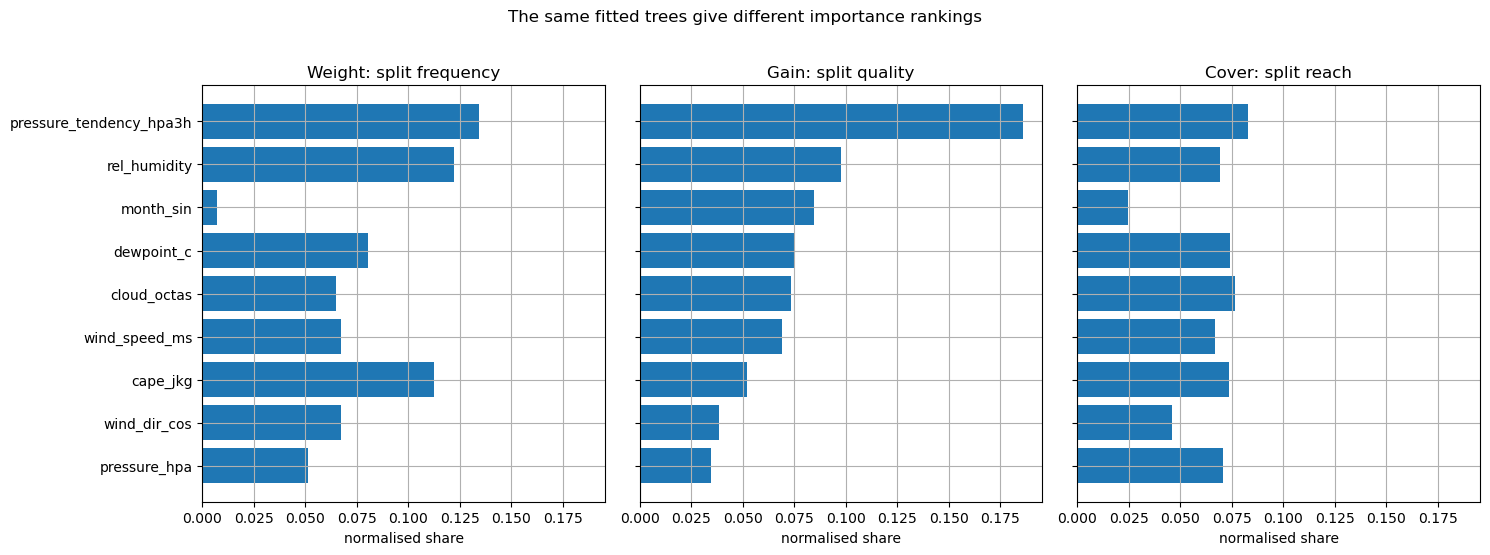

In [29]:
def extract_builtin_importance(booster, feature_names):
	"""Return raw and column-normalised built-in split importance scores."""
	importance_types = ["weight", "gain", "cover", "total_gain", "total_cover"]
	raw = pd.DataFrame({
		kind: pd.Series(booster.get_score(importance_type=kind), dtype=float)
		for kind in importance_types
	}).reindex(feature_names).fillna(0.0)
	raw["weight"] = raw["weight"].astype(int)

	shares = raw[["weight", "gain", "cover"]].div(
		raw[["weight", "gain", "cover"]].sum(axis=0).replace(0, np.nan),
		axis="columns",
	).fillna(0.0)
	ranks = raw[["weight", "gain", "cover"]].rank(
		method="min", ascending=False
	).astype("Int64")

	comparison = pd.concat(
		[
			raw,
			shares.add_suffix("_share"),
			ranks.add_suffix("_rank"),
		],
		axis=1,
	)
	return comparison, shares


def builtin_importance_demo(seed=67, num_boost_round=120, max_depth=3):
	if not HAS_XGBOOST:
		print("xgboost is not installed. Install it with: pip install xgboost")
		return None, None

	tmp = make_meteo_data(n=3200, seed=seed, missingness=0.12)
	X = tmp[FEATURES]
	y = np.log1p(tmp["rain_next_6h_mm"])
	train_idx, _ = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 1)
	dtrain = xgb.DMatrix(
		X.iloc[train_idx],
		label=y.iloc[train_idx],
		feature_names=FEATURES,
		missing=np.nan,
	)
	booster = xgb.train(
		{
			"objective": "reg:squarederror",
			"eta": 0.08,
			"max_depth": int(max_depth),
			"min_child_weight": 3.0,
			"subsample": 0.85,
			"colsample_bytree": 0.9,
			"tree_method": "hist",
			"seed": int(seed),
			"nthread": 2,
		},
		dtrain,
		num_boost_round=int(num_boost_round),
		verbose_eval=False,
	)

	comparison, shares = extract_builtin_importance(booster, FEATURES)
	used = comparison["weight"] > 0
	gain_identity = np.allclose(
		comparison.loc[used, "total_gain"],
		comparison.loc[used, "weight"] * comparison.loc[used, "gain"],
	)
	cover_identity = np.allclose(
		comparison.loc[used, "total_cover"],
		comparison.loc[used, "weight"] * comparison.loc[used, "cover"],
	)
	print(f"Check: total_gain = weight × gain: {gain_identity}")
	print(f"Check: total_cover = weight × cover: {cover_identity}")

	display_columns = [
		"weight", "gain", "cover",
		"weight_rank", "gain_rank", "cover_rank",
	]
	display(
		comparison.sort_values("gain", ascending=False)[display_columns]
		.round({"gain": 3, "cover": 1})
	)

	# Show the union of the six leading features under each definition.
	top_features = []
	for kind in ["weight", "gain", "cover"]:
		top_features.extend(shares.nlargest(6, kind).index.tolist())
	top_features = list(dict.fromkeys(top_features))
	feature_order = shares.loc[top_features].sort_values("gain").index

	fig, axes = plt.subplots(1, 3, figsize=(15, 5.4), sharey=True, sharex=True)
	titles = {
		"weight": "Weight: split frequency",
		"gain": "Gain: split quality",
		"cover": "Cover: split reach",
	}
	for ax, kind in zip(axes, ["weight", "gain", "cover"]):
		ax.barh(feature_order, shares.loc[feature_order, kind])
		ax.set_title(titles[kind])
		ax.set_xlabel("normalised share")
	fig.suptitle("The same fitted trees give different importance rankings", y=1.02)
	plt.tight_layout()
	plt.show()

	return booster, comparison


if HAS_XGBOOST:
	_builtin_importance_booster, builtin_importance_scores = builtin_importance_demo()
else:
	print("Install xgboost to run the built-in importance demonstration.")

### 18.2 Partial dependence

Partial dependence asks how the model's mean prediction changes when one feature is set to a grid of values while the other observed feature values are retained. It can give us additional information that split importance cannot provide, but it can also create unrealistic combinations when meteorological predictors are correlated (and so we must be careful that it does not trip up our interpretations!)

In [30]:
def partial_dependence_scratch(model, X_reference, feature_index, grid):
	X_reference = np.asarray(X_reference, dtype=float)
	values = []
	for v in grid:
		X_tmp = X_reference.copy()
		X_tmp[:, feature_index] = v
		values.append(model.predict(X_tmp).mean())
	return np.array(values)

def scratch_partial_dependence_demo(feature="rel_humidity", seed=61):
	tmp, X_train, X_valid, y_train, y_valid, objective, train_idx, valid_idx = prepare_meteo_arrays(seed=seed, n=2600, missingness=0.12, target="log_rain")
	model = ScratchXGBoost(
		n_estimators=35,
		learning_rate=0.12,
		objective=objective,
		max_depth=2,
		min_child_weight=5,
		reg_lambda=2,
		max_bin=32,
		max_candidates=48,
		random_state=seed,
	)
	model.fit(X_train, y_train, feature_names=FEATURES, eval_set=(X_valid, y_valid))

	j = FEATURES.index(feature)
	grid = np.linspace(np.nanpercentile(X_valid[:, j], 2), np.nanpercentile(X_valid[:, j], 98), 80)
	pd_values = partial_dependence_scratch(model, X_valid[:500], j, grid)

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	axes[0].plot(grid, pd_values)
	axes[0].set_xlabel(feature)
	axes[0].set_ylabel("mean predicted log1p rain")
	axes[0].set_title("Partial dependence")

	fi = model.feature_importance().head(10).iloc[::-1]
	axes[1].barh(fi.index, fi.values)
	axes[1].set_title("Gain importance")
	plt.tight_layout()
	plt.show()

if HAS_WIDGETS:
	display(widgets.interactive(
		scratch_partial_dependence_demo,
		feature=widgets.Dropdown(options=FEATURES, value="rel_humidity", description="feature"),
		seed=widgets.IntSlider(value=61, min=0, max=99, step=1, description="seed"),
	))
else:
	scratch_partial_dependence_demo()

interactive(children=(Dropdown(description='feature', index=2, options=('temp_c', 'dewpoint_c', 'rel_humidity'…

### 18.3 SHAP values

SHAP-style attributions decompose individual predictions into feature contributions. They are useful for local explanations and can be summarised globally, but correlated predictors can share or exchange attribution in an undefined way. The optional cell below requires the `shap` package.

In [31]:
def shap_optional_demo(seed=71):
	if not HAS_XGBOOST:
		print("xgboost is not installed.")
		return
	try:
		import shap
	except Exception:
		print("shap is not installed. Install it with: pip install shap")
		return

	tmp = make_meteo_data(n=2500, seed=seed, missingness=0.12)
	X = tmp[FEATURES]
	y = np.log1p(tmp["rain_next_6h_mm"])
	train_idx, valid_idx = train_valid_split(len(tmp), valid_fraction=0.25, seed=seed + 4)

	model = xgb.XGBRegressor(
		n_estimators=200,
		learning_rate=0.05,
		max_depth=3,
		min_child_weight=3,
		subsample=0.8,
		colsample_bytree=0.8,
		objective="reg:squarederror",
		tree_method="hist",
		random_state=seed,
	)
	model.fit(X.iloc[train_idx], y.iloc[train_idx])

	sample = X.iloc[valid_idx].sample(250, random_state=seed)
	explainer = shap.TreeExplainer(model)
	shap_values = explainer.shap_values(sample)
	shap.summary_plot(shap_values, sample, show=True)
def shap_widget(run=False, seed=71):
	if not run:
		print("Tick 'run' to train the optional SHAP demo.")
		return
	shap_optional_demo(seed=seed)

if HAS_WIDGETS:
	display(widgets.interactive(
		shap_widget,
		run=widgets.Checkbox(value=False, description="run"),
		seed=widgets.IntSlider(value=71, min=0, max=99, step=1, description="seed"),
	))
else:
	if PREGENERATE_FIGURES:
		shap_optional_demo()
	else:
		print("Call shap_optional_demo() manually to run this optional section.")


interactive(children=(Checkbox(value=False, description='run'), IntSlider(value=71, description='seed', max=99…

## 19. Time-aware validation and leakage

Meteorology is full of leakage traps.

Examples:

- using observations that would not be available at forecast issue time;
- using accumulated rainfall predictors that overlap the target period;
- randomly splitting autocorrelated station-time data so near-duplicates appear in train and validation;
- allowing station identity to memorise local climatology when the deployment requires new-site generalisation.

For real work, we must design out train/val/test splot carefully:

- split by time for future forecasting;
- split by station for new-station generalisation;
- block spatially or temporally if correlation length-scales matter;
- test rare events separately.

Train rows: 2074, validation rows: 726
Validation period dayofyear: 271-365
Validation RMSE log1p rain: 0.7397


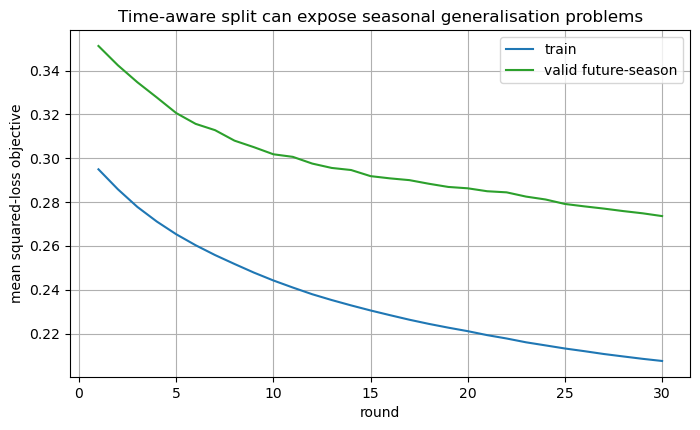

In [32]:
def time_split_demo(seed=81):
	tmp = make_meteo_data(n=2800, seed=seed, missingness=0.12)
	X = tmp[FEATURES].to_numpy(float)
	y = np.log1p(tmp["rain_next_6h_mm"].to_numpy())

	train_idx = np.where(tmp["dayofyear"].to_numpy() <= 270)[0]
	valid_idx = np.where(tmp["dayofyear"].to_numpy() > 270)[0]

	model = ScratchXGBoost(
		n_estimators=30,
		learning_rate=0.1,
		objective="squared",
		max_depth=2,
		min_child_weight=5,
		reg_lambda=2,
		max_bin=32,
		max_candidates=32,
		random_state=seed,
	)
	model.fit(X[train_idx], y[train_idx], feature_names=FEATURES, eval_set=(X[valid_idx], y[valid_idx]))

	pred = model.predict(X[valid_idx])
	print(f"Train rows: {len(train_idx)}, validation rows: {len(valid_idx)}")
	print(f"Validation period dayofyear: {tmp.loc[valid_idx, 'dayofyear'].min()}-{tmp.loc[valid_idx, 'dayofyear'].max()}")
	print(f"Validation RMSE log1p rain: {rmse(y[valid_idx], pred):.4f}")

	hist = model.history_frame()
	plt.figure(figsize=(8, 4.5))
	plt.plot(hist["round"], hist["train_loss"], label="train")
	plt.plot(hist["round"], hist["valid_loss"], label="valid future-season")
	plt.xlabel("round")
	plt.ylabel("mean squared-loss objective")
	plt.title("Time-aware split can expose seasonal generalisation problems")
	plt.legend()
	plt.show()

time_split_demo()

## 20. Hyperparameter map

| Lever | Mathematical location | What happens when increased | Meteorological note |
|---|---|---|---|
| `n_estimators` / boosting rounds | number of additive trees | more capacity, more overfitting risk | use early stopping with time-aware validation |
| `eta` / `learning_rate` | multiplier on each tree | smaller updates, usually needs more trees | often improves stability on noisy observations |
| `max_depth` | tree structure | higher-order interactions | interactions may be real, but can memorise regimes |
| `min_child_weight` | minimum child Hessian | fewer small leaves | helpful for rare-event noise |
| `gamma` | split cost | fewer splits | useful when tiny gains are meteorological artefacts |
| `lambda` | L2 on leaf values | shrinks leaves | smooths updates; safer default than zero |
| `alpha` | L1 on leaf values | zeros weak leaves | can simplify models |
| `subsample` | rows per tree | more randomness, lower variance | watch temporal dependence |
| `colsample_bytree` / `colsample_bynode` | features per tree/node | more feature randomness | reduces proxy overuse among correlated predictors |
| `max_bin` | histogram resolution | more exact splits, slower | coarse bins may miss sharp thresholds |
| `tree_method` | split algorithm | `hist` is usually fast | categorical support and GPU options depend on method/version |
| `scale_pos_weight` | class weights | emphasises positives | useful for rare rain/no-rain or extremes |
| `monotone_constraints` | allowed tree splits/leaf ordering | enforces scientific direction | strong global assumption; validate carefully |
| `interaction_constraints` | allowed feature interactions | limits interaction structure | can encode scientific grouping |
| `missing` / `np.nan` | sparsity-aware routing | learnt default direction | do not hide informative missingness by blind imputation |

## 21. Capstone exercises

Try these in order.

### Exercise A — make a stump by hand

1. Use `single_feature_split_report`.
2. Set `feature="pressure_tendency_hpa3h"`.
3. Move the threshold percentile.
4. Explain why the best split has the sign it has.

<details>
<summary>Hint</summary>

Falling pressure means negative tendency. In this simulated world, negative pressure tendency is associated with higher rain risk.
</details>

### Exercise B — overfit deliberately

1. In `run_scratch_xgb_dashboard`, set `max_depth=5`, `eta=0.4`, `rounds=80`, `gamma=0`, `lambda=0`.
2. Watch training and validation loss.
3. Add `lambda`, `gamma`, and smaller `eta`.

### Exercise C — missingness as signal

1. In `missing_data_playground`, set `missing_signal` positive and negative.
2. Observe the learnt default direction.
3. Explain when imputation might destroy information.

### Exercise D — classify rain occurrence

1. In `rain_classifier_threshold_demo`, change `scale_pos_weight`.
2. Move the decision threshold.
3. Trade off misses and false alarms.

### Exercise E — monotonicity

1. Run `monotone_constraints_demo(constrained=False)`.
2. Run it again with `constrained=True`.
3. Compare partial dependence curves.
4. Decide whether you trust each constraint meteorologically.

### Exercise F — build a better workflow

Design a real experiment:

- choose a target: occurrence, amount, quantile, threshold exceedance;
- choose validation: future time, new station, new region, or cross-season;
- choose loss and metric;
- choose physical constraints;
- define leakage checks.

## 22. Formula sheet

### Additive model

$$
\hat{y}^{(t)} = \hat{y}^{(t-1)}+\eta f_t(x)
$$

### Taylor expansion

$$
\ell(y_i,\hat{y}_i+f_i)
\approx
\ell(y_i,\hat{y}_i)+g_i f_i+\frac{1}{2}h_i f_i^2
$$

### Leaf sums

$$
G_j=\sum_{i\in I_j}g_i,\qquad H_j=\sum_{i\in I_j}h_i
$$

### Optimal leaf value, L2 only

$$
w_j^*=-\frac{G_j}{H_j+\lambda}
$$

### Optimal leaf value, L1 and L2

$$
w_j^*=
-\frac{\operatorname{sign}(G_j)\max(|G_j|-\alpha,0)}
{H_j+\lambda}
$$

### Split gain

$$
\text{Gain}
=
\frac{1}{2}
\left[
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-
\frac{G^2}{H+\lambda}
\right]
-\gamma
$$

### Logistic derivatives

$$
p=\sigma(m),\qquad g=p-y,\qquad h=p(1-p)
$$

### Squared-error derivatives

$$
g=m-y,\qquad h=1
$$

### Poisson derivatives

$$
\mu=\exp(m),\qquad g=\mu-y,\qquad h=\mu
$$

## 23. Further reading

- Tianqi Chen and Carlos Guestrin, **[XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754)**, KDD 2016 / arXiv:1603.02754.  
  The paper describes the regularised second-order objective, sparsity-aware split finding, weighted quantile sketch, and systems design.

- XGBoost documentation: **[Parameters](https://xgboost.readthedocs.io/en/stable/parameter.html)**.  
  Useful for exact definitions of `gamma`, `max_depth`, `min_child_weight`, `subsample`, `colsample_*`, `lambda`, `alpha`, `max_bin`, `grow_policy`, categorical parameters, and DART parameters.

- XGBoost documentation: **[Custom Objective and Evaluation Metric](https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html)** and **[Advanced Usage of Custom Objectives](https://xgboost.readthedocs.io/en/latest/tutorials/advanced_custom_obj.html)**.  
  Useful for the gradient/Hessian contract and the conditions under which custom objectives behave well.

- XGBoost documentation: **[Monotonic Constraints](https://xgboost.readthedocs.io/en/latest/tutorials/monotonic.html)**.  
  Useful for enforcing increasing/decreasing relationships and for understanding caveats with histogram methods.